In [12]:
import json
import os
import re
import dspy
import litellm

# ============================================
# 1. CARREGAMENTO DE SEGREDOS E CONFIGURAÇÃO INICIAL
# ============================================

def load_api_key():
    """Carrega a chave da API do OpenRouter de forma segura."""
    try:
        with open("secrets.json", "r") as f:
            secrets = json.load(f)
        api_key = secrets.get("OPENROUTER_KEY", "")
    except FileNotFoundError:
        print("Arquivo secrets.json não encontrado. Tentando variável de ambiente.")
        api_key = os.environ.get("OPENROUTER_KEY", "")

    if not api_key:
        raise ValueError("Erro CRÍTICO: Chave de API não encontrada! Configure 'secrets.json' ou a env var 'OPENROUTER_KEY'.")
    
    return api_key

API_KEY = load_api_key()

# Configurações globais do LiteLLM (backend do DSPy)
os.environ["OPENROUTER_KEY"] = API_KEY
os.environ["OPENROUTER_BASE"] = "https://openrouter.ai/api/v1"

# Headers para evitar bloqueios e identificar sua app (boas práticas OpenRouter)
# 2. Configurar headers customizados para evitar bloqueio do Cloudflare
custom_headers = {
    "accept": "*/*",
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json",
}

# Configurações do LiteLLM
litellm.drop_params = True
litellm.headers = custom_headers
# litellm.set_verbose = True # Descomente para debug detalhado

# ============================================
# 2. DEFINIÇÃO DOS IDs NO OPENROUTER
# ============================================
# Verifique sempre a lista atualizada em https://openrouter.ai/models

MODEL_MAP = {
    # Modelos Premium
    "gpt4o_mini": "openai/gpt-4o-mini",  # Modelo padrão
    "claude_haiku": "anthropic/claude-3.5-haiku",  # Meta-Juiz
    "qwen3_30b": "qwen/qwen3-30b-a3b-thinking-2507",  # Multilingual Thinking
    "mimo_v2_flash": "xiaomi/mimo-v2-flash",  # Multilingual Thinking Best

    # Modelos Free do OpenRouter
    "nemotron_12b": "nvidia/nemotron-nano-12b-v2-vl:free",  # Free Models
    "deepseek_r1": "deepseek/deepseek-r1-0528:free",  # Free Models
    "arcee_trinity": "arcee-ai/trinity-large-preview:free"  # Free Models


}

# ============================================
# 3. INSTANCIAÇÃO DOS MODELOS DSPy (MODULAR)
# ============================================

def create_dspy_lm(model_id, alias):
    """Cria instâncias dspy.LM configuradas via OpenRouter."""
    print(f"Configurando {alias} ({model_id})")
    return dspy.LM(
        model=model_id,
        api_key=API_KEY,
        api_base="https://openrouter.ai/api/v1",
        temperature=0.0,
        max_tokens=2000,
        custom_llm_provider="openai",  # OpenRouter compatível
    )

# Wrapper para o Nemotron que remove '%' de probabilidades no JSON.
class NemotronPercentCleaningLM(dspy.BaseLM):
    """Wrapper para o Nemotron que remove '%' de probabilidades no JSON.

    Ele percorre recursivamente o objeto de saída do LM e, em qualquer string,
    remove o caractere '%' logo após números (ex.: '40%' -> '40').
    """

    def __init__(self, base_lm):
        self.base_lm = base_lm

    def _clean_obj(self, obj):
        # Limpa strings individuais
        if isinstance(obj, str):
            return re.sub(r"(\d+(?:\.\d+)?)\s*%", r"\1", obj)

        # Lista: limpa item a item
        if isinstance(obj, list):
            return [self._clean_obj(x) for x in obj]

        # Dicionário: limpa valores
        if isinstance(obj, dict):
            return {k: self._clean_obj(v) for k, v in obj.items()}

        # Objetos com __dict__: limpa atributos recursivamente
        if hasattr(obj, "__dict__"):
            for attr, val in obj.__dict__.items():
                setattr(obj, attr, self._clean_obj(val))

        return obj

    def __getattr__(self, name):
        # Qualquer atributo não definido aqui é delegado ao LM base
        return getattr(self.base_lm, name)

    def __call__(self, *args, **kwargs):
        result = self.base_lm(*args, **kwargs)
        return self._clean_obj(result)

    async def acall(self, *args, **kwargs):
        # Versão assíncrona, se usada pelo DSPy
        result = await self.base_lm.acall(*args, **kwargs)
        return self._clean_obj(result)

    def complete(self, *args, **kwargs):
        # Em alguns caminhos o DSPy pode chamar .complete diretamente
        result = self.base_lm.complete(*args, **kwargs)
        return self._clean_obj(result)

# ============================================
# INSTANCIAÇÃO DOS MODELOS
# ============================================

juri_modelos = {}

# Modelo Padrão
juri_modelos["gpt4o_mini"] = create_dspy_lm(MODEL_MAP["gpt4o_mini"], "GPT-4o-mini (Padrão)")

# Meta-Juiz
juri_modelos["claude_haiku"] = create_dspy_lm(MODEL_MAP["claude_haiku"], "Claude 3.5 Haiku (Meta-Juiz)")

# Qwen3 30B
juri_modelos["qwen3_30b"] = create_dspy_lm(MODEL_MAP["qwen3_30b"], "Qwen3 30B")

# Mimo V2 Flash
juri_modelos["mimo_v2_flash"] = create_dspy_lm(MODEL_MAP["mimo_v2_flash"], "Mimo V2 Flash")

# Modelos do Júri (Free)
juri_modelos["nemotron_12b"] = create_dspy_lm(MODEL_MAP["nemotron_12b"], "Nemotron 12B")
# Wrapper específico para o Nemotron: remove '%' do JSON antes do parse
juri_modelos["nemotron_12b"] = NemotronPercentCleaningLM(juri_modelos["nemotron_12b"])
juri_modelos["deepseek_r1"] = create_dspy_lm(MODEL_MAP["deepseek_r1"], "Deepseek R1")
juri_modelos["arcee_trinity"] = create_dspy_lm(MODEL_MAP["arcee_trinity"], "Arcee Trinity")



# Configuração padrão
dspy.configure(lm=juri_modelos["nemotron_12b"])
dspy.settings.cache = None

print(f"\n✅ {len(juri_modelos)} modelos configurados:")
print(f"   - Anotador Padrão: GPT-4o-mini")
print(f"   - Melhor Juiz: Claude 3.5 Haiku")
print(f"   - Multilingual Thinking: Qwen3 30B")
print(f"   - Multilingual Thinking Best: Mimo V2 Flash")
print(f"   - Free Models: Nemotron 12B, Deepseek R1, Arcee AI Trinity Large")

Configurando GPT-4o-mini (Padrão) (openai/gpt-4o-mini)
Configurando Claude 3.5 Haiku (Meta-Juiz) (anthropic/claude-3.5-haiku)
Configurando Qwen3 30B (qwen/qwen3-30b-a3b-thinking-2507)
Configurando Mimo V2 Flash (xiaomi/mimo-v2-flash)
Configurando Nemotron 12B (nvidia/nemotron-nano-12b-v2-vl:free)
Configurando Deepseek R1 (deepseek/deepseek-r1-0528:free)
Configurando Arcee Trinity (arcee-ai/trinity-large-preview:free)

✅ 7 modelos configurados:
   - Anotador Padrão: GPT-4o-mini
   - Melhor Juiz: Claude 3.5 Haiku
   - Multilingual Thinking: Qwen3 30B
   - Multilingual Thinking Best: Mimo V2 Flash
   - Free Models: Nemotron 12B, Deepseek R1, Arcee AI Trinity Large


In [13]:
# 1. Definir a Signature e Role (Com Verbalized Sampling)
class ClassifyDepression(dspy.Signature):
    """Você é um especialista em psiquiatria. Sua tarefa é ler um texto, classificá-lo quanto ao grau de depressão (0 - Ausente, 1 - Leve, 2 - Moderada, 3 - Grave) e explorar a distribuição de possíveis classificações antes de decidir."""
    
    text = dspy.InputField(desc="Texto a ser analisado conforme crítérios do DSM-5 e do Inventário de Beck")
    probability = dspy.OutputField(desc="Probabilidade estimada para cada classe de depressão, conforme a distribuição de probabilidades.", format="json sem caracteres especiais e normalizado entre 0.0 e 1.0")
    rationale = dspy.OutputField(desc="Sintomas e Raciocínio clínico para a classificação, descrito em uma única sentença")
    severity = dspy.OutputField(desc="Classe da depressão: 0, 1, 2 ou 3.")

# Definir o predictor com ChainOfThought 
class classifier(dspy.Module):
    def __init__(self):
        self.classifier = dspy.ChainOfThought(ClassifyDepression) 
    
    def forward(self, text):
        return self.classifier(text=text)

# Criar predictor
depression_cot_predictor = dspy.ChainOfThought(ClassifyDepression)

print("✅ Signature e predictor criados com sucesso!")

✅ Signature e predictor criados com sucesso!


In [14]:
# Teste básico do Preditor

# 3. Exemplo de uso com o texto fornecido
novo_texto = "Dias atrás eu fui a uma festa e percebi o quanto a pandemia me isolou, pois não fiz amigos e me senti extremamente solitário durante o show. Com 19 anos, enfrento a depressão, que já me acompanhava há muito tempo, e me afastei das pessoas que se importavam comigo. Sempre fui aquele garoto conservador que se fechou para o mundo, e mesmo não sendo tão introvertido, tenho dificuldade em interagir em público. No entanto, encontrei um amigo que me apresentou a outras pessoas, e uma delas me tratou como um amigo, algo que eu realmente senti falta. Essa interação me fez perceber o quanto preciso de conexões e que não posso viver sozinho; definitivamente, preciso voltar à psicóloga para lidar com esses sentimentos."

# Chain-of-Thought prediction (COT)
resposta_cot = depression_cot_predictor(text=novo_texto)
print(f"Probabilidades: {resposta_cot.probability}\nRaciocínio: {resposta_cot.rationale}\nClasse: {resposta_cot.severity}")

Probabilidades: 2
Raciocínio: A classificação moderada reflete a presença de sintomas significativos (como isolamento e solidão) combinados com a busca ativa por ajuda, sugerindo que a depressão afeta a vida diária, mas não impede totalmente a funcionalidade.
Classe: 2


In [15]:
import pandas as pd

# ---------------------------------------------------------
# 2. Preparação dos Dados com as melhores predições do GPT-4o-mini no Seed

gold_df = pd.read_csv("gold_standard_depseverity.csv")

# Filtrando índices das instâncias selecionadas e atribuindo a classe em zero_shot_4omini

""" Top 20 amostras anotadas GPT-4o-mini (índices)

Ausente: 1,2,6,9 (ausente) e 16(era leve)
Leve: 13,15(leve), 4(era ausente), 21 e 28 (eram moderada)
Moderada: 27,29(moderada), 14 e 25 (eram leve), 35 (era grave)
Grave: 30,32,33,38(grave), 31(era moderada)"""

# Definir os índices para cada classe
ausente_idx = [1,2,6,9,16]
leve_idx = [13,15,4,21,28]
moderada_idx = [27,29,14,25,35]
grave_idx = [30,31,32,33,38]

# Inicializar a nova coluna com NaN
gold_df['zero_shot_4omini'] = pd.NA

# Atribuir as classes conforme os grupos de índices
gold_df.loc[ausente_idx, 'zero_shot_4omini'] = 'Ausente'
gold_df.loc[leve_idx, 'zero_shot_4omini'] = 'Leve'
gold_df.loc[moderada_idx, 'zero_shot_4omini'] = 'Moderada'
gold_df.loc[grave_idx, 'zero_shot_4omini'] = 'Grave'

gold_df_teste = gold_df.copy()
gold_df_teste.dropna(subset=['zero_shot_4omini'], inplace=True)
gold_df_teste['zero_shot_4omini'] = gold_df_teste['zero_shot_4omini'].map({'Ausente': 0, 'Leve': 1, 'Moderada': 2, 'Grave': 3})
gold_df_teste 

,text,severity,zero_shot_4omini
1,"Atualmente, estou em dúvida se sofro de ansied...",0,0
2,Eu não tenho ideia. Eu medito duas vezes ao di...,0,0
4,"Talvez 2-3 brigas malucas, mas nada sério. Joe...",0,1
6,Momento frustrante original: <url> Estou escre...,0,0
9,"A participação leva aproximadamente 5 minutos,...",0,0
13,Eu queria ir para essa escola de arte em uma c...,1,1
14,"Sou um homem de 23 anos, estudante em uma cida...",1,2
15,Eu não me sinto bem comigo mesma porque precis...,1,1
16,- Fobia específica: o tipo mais comum. É quand...,1,0
21,"Às vezes, quando finalmente saía da cama e me ...",2,1


In [16]:
# Métricas do GPT-4o-mini no Seed (Sem Few-Shot)

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, classification_report

# Convertendo as colunas relevantes para inteiros
y_true = gold_df_teste['severity'].astype(int).values
y_pred = gold_df_teste['zero_shot_4omini'].astype(int).values

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Relatório de classificação
report = classification_report(y_true, y_pred)
print("Relatório de Classificação:")
print(report)

# Acurácia
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

# Precisão Macro e Weighted
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")

# Recall Macro e Weighted
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")

# F1 Score Macro e Weighted
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# Quadratic Weighted Kappa (QWK)
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")


Confusion Matrix:
[[4 1 0 0]
 [1 2 1 0]
 [0 2 3 0]
 [0 0 1 5]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.40      0.50      0.44         4
           2       0.60      0.60      0.60         5
           3       1.00      0.83      0.91         6

    accuracy                           0.70        20
   macro avg       0.70      0.68      0.69        20
weighted avg       0.73      0.70      0.71        20

Accuracy: 0.7000
Precision (Macro): 0.7000
Precision (Weighted): 0.7300
Recall (Macro): 0.6833
Recall (Weighted): 0.7000
F1 Score (Macro): 0.6884
F1 Score (Weighted): 0.7116
Quadratic Weighted Kappa (QWK): 0.8846


In [17]:
# Criar um DataFrame apenas com as instâncias que não estão em gold_df_teste, usando os índices preservados
restantes_df = gold_df.loc[~gold_df.index.isin(gold_df_teste.index)].copy()
restantes_df.drop(columns=['zero_shot_4omini'], inplace=True)
restantes_df

,text,severity
0,Estou me sentindo completamente isolado e desc...,0
3,Eu (30F) casei com meu marido (31M) há cerca d...,0
5,"Recentemente, tive que ficar no apartamento de...",0
7,"A comida que normalmente compramos custa $8, i...",0
8,Pós-post: não se preocupe com esta parte que e...,0
10,"Daqui a três meses, faço 25 anos e mal saio de...",1
11,Estou desesperado e confuso. Sempre soube que ...,1
12,"Recentemente, fui a uma festa e percebi o quan...",1
17,"Oi pessoal, sou um homem de 22 anos que tem en...",1
18,"Eu não sei o que fazer. A polícia não ajuda, p...",1


In [18]:
# Adaptar restantes_df e gold_df_teste como exemplos DSPy
train_set = [dspy.Example(text=row['text'], severity=str(row['severity'])).with_inputs('text') for _, row in restantes_df.iterrows()]
dev_set = [dspy.Example(text=row['text'], severity=str(row['severity'])).with_inputs('text') for _, row in gold_df_teste.iterrows()]

In [19]:
# Definição das métricas para o otimizador BFRS

from dspy.evaluate import Evaluate
from sklearn.metrics import cohen_kappa_score, classification_report

# ---------------------------------------------------------
# 3. Métricas usada DENTRO do otimizador DSPy
# ---------------------------------------------------------

# Métrica LOCAL (Ponderada por distância)
def metric_dist_penalty(gold, pred, trace=None):
    """Métrica de distância para o otimizador."""
    try:
        g = int(gold.severity)
        p = int(pred.severity)
    except:
        return 0.0 # Falha de formato
    
    dist = abs(g - p)
    
    if dist == 0: return 1.0   # Perfeito
    if dist == 1: return 0.5   # Erro leve (ajuda QWK)
    return 0.0                 # Erro grave

# Métrica LOCAL (Accuracy)
def classification_metric(gold, pred, trace=None):
    """Métrica simples (Accuracy) para o otimizador."""
    gold_severity = str(gold.severity).strip()
    pred_severity = str(pred.severity).strip()

    # Retorna 1.0 (sucesso) se forem iguais, 0.0 (falha)
    return 1.0 if gold_severity == pred_severity else 0.0  

# Configurar o avaliador
evaluator = Evaluate(devset=dev_set, metric=classification_metric, num_threads=4, display_progress=True)

In [20]:
import dspy
from dspy.teleprompt import BootstrapFewShotWithRandomSearch  

# ============================================
# PIPELINE CENTRALIZADO DE COMPILAÇÃO DO JÚRI
# ============================================

def compile_jury_models(
    jury_models_dict,
    train_set,
    dev_set,
    metric_fn,
    teacher_lm=None,
    max_bootstrapped_demos=4,
    num_candidate_programs=10
):
    """
    Pipeline centralizado para compilar modelos do júri usando dspy.context.
    
    Args:
        jury_models_dict: Dicionário com {nome_modelo: dspy.LM}
        train_set: Dataset de treino (lista de dspy.Example)
        dev_set: Dataset de validação (lista de dspy.Example)
        metric_fn: Função de métrica para o otimizador
        teacher_lm: LM usado como "professor" para gerar thoughts (padrão: gpt4o_mini)
        max_bootstrapped_demos: Número máximo de demonstrações no prompt
        num_candidate_programs: Número de programas candidatos para testar
    
    Returns:
        Dicionário com {nome_modelo: compiled_classifier}
    """
    # Usar gpt4o_mini como teacher padrão se não especificado
    if teacher_lm is None:
        teacher_lm = jury_models_dict.get("gpt4o_mini")
        if teacher_lm is None:
            raise ValueError("teacher_lm não especificado e 'gpt4o_mini' não encontrado em jury_models_dict")
    
    # Instanciar o Otimizador BFRC
    optimizer = BootstrapFewShotWithRandomSearch(
        metric=metric_fn,
        max_bootstrapped_demos=max_bootstrapped_demos,
        num_candidate_programs=num_candidate_programs,
        teacher_settings={'lm': teacher_lm}
    )
    
    # Dicionário para armazenar os programas compilados
    compiled_classifiers_jury = {}
    
    print(f"\n{'='*60}")
    print(f"Iniciando compilação de {len(jury_models_dict)} modelos do júri")
    print(f"{'='*60}\n")
    
    # Iterar sobre cada modelo do júri e compilar usando dspy.context
    for idx, (nome_lm, lm) in enumerate(jury_models_dict.items(), 1):
        print(f"[{idx}/{len(jury_models_dict)}] Compilando: {nome_lm}")
        
        try:
            # Usar dspy.context para configurar o LM para este modelo específico
            with dspy.context(lm=lm):
                # Criar instância não compilada do classificador
                juror_uncompiled_classifier = classifier()
                
                # Compilar o classificador com o otimizador
                juror_compiled_classifier = optimizer.compile(
                    juror_uncompiled_classifier,
                    trainset=train_set,
                    valset=dev_set
                )
                
                # Armazenar o classificador compilado
                compiled_classifiers_jury[nome_lm] = juror_compiled_classifier
                print(f"✅ {nome_lm} compilado com sucesso!\n")
                
        except Exception as e:
            print(f"❌ Erro ao compilar {nome_lm}: {e}\n")
            # Continuar com os próximos modelos mesmo se um falhar
            continue
    
    print(f"{'='*60}")
    print(f"Compilação concluída! {len(compiled_classifiers_jury)}/{len(jury_models_dict)} modelos compilados")
    print(f"{'='*60}\n")
    
    return compiled_classifiers_jury

# ============================================
# EXECUTAR COMPILAÇÃO DO JÚRI
# ============================================

# Executar o pipeline centralizado
compiled_classifiers_jury = compile_jury_models(
    jury_models_dict=juri_modelos,
    train_set=train_set,
    dev_set=dev_set,
    metric_fn=classification_metric,
    teacher_lm=juri_modelos["gpt4o_mini"],  # Usar GPT-4o-mini como teacher
    max_bootstrapped_demos=4,
    num_candidate_programs=10
)

Going to sample between 1 and 4 traces per predictor.
Will attempt to bootstrap 10 candidate sets.

Iniciando compilação de 7 modelos do júri

[1/7] Compilando: gpt4o_mini
Average Metric: 1.00 / 2 (50.0%):   5%|▌         | 1/20 [00:00<00:00, 27.03it/s]

Average Metric: 10.00 / 20 (50.0%): 100%|██████████| 20/20 [00:00<00:00, 127.95it/s]

2026/03/11 15:42:17 INFO dspy.evaluate.evaluate: Average Metric: 10.0 / 20 (50.0%)



New best score: 50.0 for seed -3
Scores so far: [50.0]
Best score so far: 50.0
Average Metric: 11.00 / 20 (55.0%): 100%|██████████| 20/20 [00:00<00:00, 110.68it/s]

2026/03/11 15:42:17 INFO dspy.evaluate.evaluate: Average Metric: 11.0 / 20 (55.0%)


...


Scores so far: [45.0, 55.0, 60.0, 60.0, 50.0, 50.0, 60.0, 60.0, 65.0, 65.0, 65.0, 60.0]
Best score so far: 65.0


 70%|███████   | 14/20 [00:00<00:00, 21.74it/s]


Bootstrapped 4 full traces after 14 examples for up to 1 rounds, amounting to 14 attempts.
Average Metric: 9.00 / 20 (45.0%): 100%|██████████| 20/20 [00:00<00:00, 101.65it/s]

2026/03/11 15:43:22 INFO dspy.evaluate.evaluate: Average Metric: 9.0 / 20 (45.0%)



Scores so far: [45.0, 55.0, 60.0, 60.0, 50.0, 50.0, 60.0, 60.0, 65.0, 65.0, 65.0, 60.0, 45.0]
Best score so far: 65.0
13 candidate programs found.
✅ arcee_trinity compilado com sucesso!

Compilação concluída! 7/7 modelos compilados



In [23]:
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

# Para cada modelo, exibir confusion matrix, classification report e Kappa de Cohen
for nome_modelo, modelo in compiled_classifiers_jury.items():
    print(f"\n{'='*10} Matriz de Confusão e Relatório de Classificação para {nome_modelo} {'='*10}")

    # Obtém o LM correspondente para garantir que o modelo correto seja usado
    lm_correspondente = juri_modelos.get(nome_modelo)
    if lm_correspondente is None:
        print(f"⚠️ Aviso: LM não encontrado para {nome_modelo}, usando padrão")
        lm_correspondente = juri_modelos["gpt4o_mini"]

    y_true = []
    y_pred = []

        # Usa dspy.context para garantir que o modelo correto seja usado
    with dspy.context(lm=lm_correspondente):
        for example in dev_set:
            try:
                pred = modelo(text=example.text)
                pred_label = str(pred.severity).strip()
                # Classes esperadas são 0,1,2,3; rótulo inválido vira 99 para não contaminar classes reais
                if pred_label not in ['0', '1', '2', '3']:
                    pred_label_int = 99
                else:
                    pred_label_int = int(pred_label)
                y_pred.append(pred_label_int)
                y_true.append(int(example.severity))
            except Exception as e:
                print(f"Erro ao processar exemplo: {e}")

    # Se houver rótulos inválidos (99), remover ambos y_true e y_pred associados
    y_true_clean = []
    y_pred_clean = []
    for yt, yp in zip(y_true, y_pred):
        if yp != 99:
            y_true_clean.append(yt)
            y_pred_clean.append(yp)

    labels = [0,1,2,3]
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_clean, y_pred_clean, labels=labels))
    print("\nClassification Report:")
    print(classification_report(y_true_clean, y_pred_clean, labels=labels))
    print("QWK (Kappa Ponderado):")
    print(cohen_kappa_score(y_true_clean, y_pred_clean, weights='quadratic'))



========== Matriz de Confusão e Relatório de Classificação para gpt4o_mini ==========
Confusion Matrix:
[[5 0 0 0]
 [1 2 0 1]
 [1 1 3 0]
 [0 0 1 5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       0.67      0.50      0.57         4
           2       0.75      0.60      0.67         5
           3       0.83      0.83      0.83         6

    accuracy                           0.75        20
   macro avg       0.74      0.73      0.73        20
weighted avg       0.75      0.75      0.74        20

QWK (Kappa Ponderado):
0.8109965635738832

========== Matriz de Confusão e Relatório de Classificação para claude_haiku ==========
Confusion Matrix:
[[4 1 0 0]
 [1 2 1 0]
 [0 1 4 0]
 [0 0 1 5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.50      0.50      0.50         4
          

In [24]:
import pandas as pd

# Avaliação lado a lado dos modelos compilados do júri
avaliacoes = []

for nome_modelo, modelo in compiled_classifiers_jury.items():
    print(f"\n{'='*20} Avaliando {nome_modelo} {'='*20}")
    # Obtém o LM correspondente para garantir que o modelo correto seja usado
    lm_correspondente = juri_modelos.get(nome_modelo)
    if lm_correspondente is None:
        print(f"⚠️ Aviso: LM não encontrado para {nome_modelo}, usando padrão")
        lm_correspondente = juri_modelos["gpt4o_mini"]
    
    # Usa a função de avaliação customizada definida abaixo
    y_true = []
    y_pred = []
    # Usa dspy.context para garantir que o modelo correto seja usado
    with dspy.context(lm=lm_correspondente):
        for example in dev_set:
            try:
                pred = modelo(text=example.text)
                pred_label = str(pred.severity).strip()
                if pred_label not in ['0', '1', '2', '3']:
                    pred_label_int = 99
                else:
                    pred_label_int = int(pred_label)
                y_pred.append(pred_label_int)
                y_true.append(int(example.severity))
            except Exception as e:
                print(f"Erro ao processar exemplo: {e}")

    # Calcular métricas
    acc = accuracy_score(y_true, y_pred)
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    avaliacoes.append({
        "Modelo": nome_modelo,
        "Accuracy": acc,
        "QWK": qwk,
        "F1_macro": f1_macro,
        "F1_weighted": f1_weighted
    })

# Mostrar resultados lado a lado
df_avaliacoes = pd.DataFrame(avaliacoes)
display(df_avaliacoes.sort_values("F1_macro", ascending=False).reset_index(drop=True))



==================== Avaliando gpt4o_mini ====================

==================== Avaliando claude_haiku ====================

==================== Avaliando qwen3_30b ====================

==================== Avaliando mimo_v2_flash ====================

==================== Avaliando nemotron_12b ====================
Erro ao processar exemplo: Adapter JSONAdapter failed to parse the LM response. 

LM Response: {`reasoning`: "O texto revela sentimentos de impotência emocional, senso de inutilidade e isolamento social, com uma menção direta à possibilidade de suicídio, indicando um risco elevado de depressão com características suicidas. A internalização de crenças limitantes familiares e a intensidade emocional sugerem um grau elevado de impacto psicológico.",`probability`: "Depressão Suícida: 30, Depressão Grave: 40, Depressão Moderada: 20, Depressão Leve: 10",`rationale`: "A menção à predestinação como justificativa para danos emocionais e a reflexão suicida, combinadas com a a

,Modelo,Accuracy,QWK,F1_macro,F1_weighted
0,claude_haiku,0.750000,0.903475,0.734091,0.754545
1,gpt4o_mini,0.750000,0.810997,0.726190,0.739286
2,nemotron_12b,0.684211,0.746667,0.673485,0.682616
3,qwen3_30b,0.650000,0.750958,0.649675,0.661104
4,arcee_trinity,0.650000,0.761905,0.634091,0.659545
5,mimo_v2_flash,0.650000,0.822695,0.607035,0.638203
6,deepseek_r1,0.650000,0.821429,0.560606,0.606061


Com base nos resultados dos modelos no Seed, observou-se que o GPT-4o-mini e o Claude Haiku possuem o melhor desempenho como anotadores. No entanto, o GPT-4o-mini foi escolhido pela capacidade de manipular textos depressivos (Ge et al. 2025; Aggarwal et al. 2025; Shao et al. 2025) e por ser cerca de 10 vezes mais barato que o Claude.

### Testes Dataset 5K

In [169]:
import gdown

link = "https://drive.google.com/file/d/162HDI09cxNB92nWeo5hXElmdiprkNyhk/view?usp=sharing"
output = "DepreRedditBR.csv"

gdown.download(link, output, quiet=False, fuzzy=True)
csv_file = output
csv_file

chunksize = 1000  # tamanho razoável para chunk; ajuste conforme necessário
sample_size = 5000

chunks = pd.read_csv(csv_file, chunksize=chunksize, encoding="utf-8")
sampled_chunks = []

for chunk in chunks:
    # Seleciona do chunk uma fração necessária para formar a amostra total
    # (isso minimiza carregar tudo na memória!)
    sampled = chunk.sample(
        n=min(sample_size, len(chunk)), random_state=42
    )
    sampled_chunks.append(sampled)
    # Se já coletamos mais de 100, podemos parar
    if sum(len(df) for df in sampled_chunks) >= sample_size:
        break

# Concatena as amostras e tira uma amostra final de 100, garantindo aleatoriedade
sample_df = pd.concat(sampled_chunks, ignore_index=True).sample(n=sample_size, random_state=42)
sample_df.reset_index(drop=True, inplace=True)

# sample_df agora contém 100 instâncias aleatórias do arquivo
sample_df

Downloading...
From (original): https://drive.google.com/uc?id=162HDI09cxNB92nWeo5hXElmdiprkNyhk
From (redirected): https://drive.google.com/uc?id=162HDI09cxNB92nWeo5hXElmdiprkNyhk&confirm=t&uuid=c69151a4-98f4-4f4b-b199-8b188d711aeb
To: c:\Users\Laerty\Jupyter_Notebook\Pesquisa_Mestrado_Laerty\anotacao_depre_reddit_br\annotation_dataset\DepreRedditBR.csv
100%|██████████| 393M/393M [00:06<00:00, 61.1MB/s] 


,text
0,"oficialmente, fui desligada por corte de gasto..."
1,"Desde criança eu sou muito tímido, sempre fui ..."
2,"Então, eu tenho um irmão que está morando em P..."
3,Contextualizando tudo. Meu nome é Luan tenho q...
4,"Bem gente, mais cedo, ele acabou terminando co..."
...,...
4995,"Eu estou um pouco orgulhoso de mim mesmo, fina..."
4996,"Me reconheço como gay, porém, vez ou outra sin..."
4997,Deixando bem claro que não vou ficar com ela. ...
4998,"É uma longa história, mas vou tentar resumir.E..."


In [ ]:
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
# Se não tiver tqdm instalado, rode: pip install tqdm
from tqdm import tqdm 

# --- Configurações ---
LIMIT_SAMPLES = 5000
MAX_WORKERS = 10  # Cuidado: Se o modelo rodar na GPU local, diminua para 2 ou 4 para não estourar a VRAM

print(f"Preparando para processar {LIMIT_SAMPLES} amostras em paralelo...")

# 1. Cria o subset (Isolamento de dados)

# 2. Função de processamento (Corrigida)
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_gpt = juri_modelos["gpt4o_mini"]
gpt4o_mini = compiled_classifiers_jury["gpt4o_mini"]


def process_row(text):
    with dspy.context(lm=lm_gpt):
        out = gpt4o_mini(text=text)
    # CORREÇÃO: Mudei 'output.probability' para 'out.probability'
    return out.severity, out.rationale, out.probability


# 3. Execução Paralela (ThreadPoolExecutor)
# ThreadPool funciona perfeitamente no Windows 11 e não exige o bloco 'if __name__ == "__main__":'
results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Usamos tqdm para mostrar uma barra de progresso no terminal do Cursor
    # O list() força a execução imediata do iterador
    results = list(tqdm(
        executor.map(process_row, sample_df['text'].tolist()), 
        total=LIMIT_SAMPLES, 
        desc="Processando"
    ))

# zip(*results) transpoe a lista de tuplas para 3 tuplas de listas
print("Desempacotando resultados...")
sample_df['severity'], sample_df['rationale'], sample_df['probs'] = zip(*results)


# 5. Salvar
#sample_df.to_csv('DepreRedditBR_parallel_5k_0.csv', index=False)
print("Concluído e salvo!")

In [29]:
import pandas as pd

df_5k = pd.read_csv('DepreRedditBR_parallel_5k_0.csv')
df_5k

,text,severity,rationale,probs
0,"Parece que ninguem quer ficar perto de mim, e,...",2,"Os sentimentos de inadequação, a dor causada p...","[0.0, 0.3, 0.5, 0.2]"
1,"Eu sou deprimido, porem tem períodos que fico ...",2,"Os sintomas descritos, como o sentimento de va...","[0.0, 0.2, 0.5, 0.3]"
2,"Boa tarde. Bem, é basicamente um desabafo. A v...",3,"Os sintomas descritos, como a sensação de esta...","[0.0, 0.1, 0.4, 0.5]"
3,"Me tirem uma duvida, ser perfeccionista ao ac...",1,"Os sintomas descritos, como perfeccionismo e d...","[0.7, 0.15, 0.1, 0.05]"
4,"Oi gente, desculpa o textão, já mandei isso em...",1,Os sintomas descritos são mais indicativos de ...,"[0.7, 0.15, 0.1, 0.05]"
...,...,...,...,...
4995,Estou ficando com uma garota que conheci tem ...,0,Os sentimentos de insegurança e a preocupação ...,"[0.9, 0.05, 0.03, 0.02]"
4996,eu sou a babaca por brigar com meu namorado na...,0,A autora demonstra uma preocupação com suas aç...,"[0.9, 0.05, 0.03, 0.02]"
4997,Minha noiva (26M) e eu (24M) temos 3 anos junt...,0,O texto expressa preocupações sobre a convivên...,"[0.9, 0.05, 0.03, 0.02]"
4998,Eu (H24) ela (M19) vou chamar ela de “A” pra s...,0,Os sentimentos de frustração e insegurança exp...,"[0.7, 0.2, 0.05, 0.05]"


In [ ]:
df_5k.severity.value_counts()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns



plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_5k, x="severity")
plt.title("Contagem por gravidade (severity)")
plt.xlabel("Gravidade (severity)")
plt.ylabel("Contagem")

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()


In [ ]:
# Usando .sample() diretamente no groupby para evitar DeprecationWarning
# Esta é a forma recomendada e mais eficiente no pandas 2.0+
sample_per_severity = (
    df_5k.groupby('severity', group_keys=False)
    .sample(n=1, random_state=42)
    .reset_index(drop=True)
)
sample_per_severity

In [ ]:
#sample_per_severity.to_csv('sample_per_severity.csv', index=False)

### Testes Dataset 10k

In [171]:
import pandas as pd

# Lê o arquivo DepreRedditBR.csv em chunks e gera uma amostra aleatória de 100 instâncias
#csv_file = "DepreRedditBR.csv"
chunksize = 1000  # tamanho razoável para chunk; ajuste conforme necessário
sample_size = 10000

chunks = pd.read_csv(csv_file, chunksize=chunksize, encoding="utf-8")
sampled_chunks = []

for chunk in chunks:
    # Seleciona do chunk uma fração necessária para formar a amostra total
    # (isso minimiza carregar tudo na memória!)
    sampled = chunk.sample(
        n=min(sample_size, len(chunk)), random_state=42
    )
    sampled_chunks.append(sampled)
    # Se já coletamos mais de 100, podemos parar
    if sum(len(df) for df in sampled_chunks) >= sample_size:
        break

# Concatena as amostras e tira uma amostra final de 100, garantindo aleatoriedade
sample_df = pd.concat(sampled_chunks, ignore_index=True).sample(n=sample_size, random_state=42)
sample_df.reset_index(drop=True, inplace=True)

# sample_df agora contém 100 instâncias aleatórias do arquivo
sample_df

,text
0,Talvez possa ser útil pra alguém. Não é a verd...
1,( Essa história vai ser longa ) Eu não ...
2,"Sim, gnt. É isso… parece fútil mas não é! Eu v..."
3,Senta que a história é grande. Meu grupo de am...
4,Estou sem vontade de continuar vivendo. De an...
...,...
9995,Estou falando de relacionamento fechado e hete...
9996,Sou uma garota e com onze anos tive minha prim...
9997,"primeiramente, sou novo aqui, criei essa conta..."
9998,"Pô, vou mandar a real aqui: sou bi, ultimament..."


In [ ]:
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
# Se não tiver tqdm instalado, rode: pip install tqdm
from tqdm import tqdm 

# --- Configurações ---
LIMIT_SAMPLES = 10000
MAX_WORKERS = 10  # Cuidado: Se o modelo rodar na GPU local, diminua para 2 ou 4 para não estourar a VRAM

print(f"Preparando para processar {LIMIT_SAMPLES} amostras em paralelo...")

# 1. Cria o subset (Isolamento de dados)

# 2. Função de processamento (Corrigida)
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_gpt = juri_modelos["gpt4o_mini"]
gpt4o_mini = compiled_classifiers_jury["gpt4o_mini"]


def process_row(text):
    with dspy.context(lm=lm_gpt):
        out = gpt4o_mini(text=text)
    # CORREÇÃO: Mudei 'output.probability' para 'out.probability'
    return out.severity, out.rationale, out.probability


# 3. Execução Paralela (ThreadPoolExecutor)
# ThreadPool funciona perfeitamente no Windows 11 e não exige o bloco 'if __name__ == "__main__":'
results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Usamos tqdm para mostrar uma barra de progresso no terminal do Cursor
    # O list() força a execução imediata do iterador
    results = list(tqdm(
        executor.map(process_row, sample_df['text'].tolist()), 
        total=LIMIT_SAMPLES, 
        desc="Processando"
    ))

# zip(*results) transpoe a lista de tuplas para 3 tuplas de listas
print("Desempacotando resultados...")
sample_df['severity'], sample_df['rationale'], sample_df['probs'] = zip(*results)


# 5. Salvar
#sample_df.to_csv('DepreRedditBR_parallel_10k.csv', index=False)
print("Concluído e salvo!")

In [ ]:
#df_10k.to_csv('DepreRedditBR_parallel_10k.csv', index=False)

In [172]:
df_10k = pd.read_csv("DepreRedditBR_parallel_10k.csv")
df_10k

,text,severity,rationale,probs
0,Talvez possa ser útil pra alguém. Não é a verd...,0,O autor demonstra uma atitude positiva e proat...,"[0.9, 0.05, 0.03, 0.02]"
1,( Essa história vai ser longa ) Eu não ...,3,"Os sintomas de trauma, solidão, sentimentos de...","[0.0, 0.1, 0.3, 0.6]"
2,"Sim, gnt. É isso… parece fútil mas não é! Eu v...",2,Os sentimentos de tristeza profunda relacionad...,"[0.0, 0.2, 0.5, 0.3]"
3,Senta que a história é grande. Meu grupo de am...,0,Embora o autor tenha enfrentado dificuldades e...,"[0.7, 0.2, 0.1, 0.0]"
4,Estou sem vontade de continuar vivendo. De an...,3,"Os sentimentos de desesperança, aversão ao pró...","[0.0, 0.05, 0.1, 0.85]"
...,...,...,...,...
9995,Estou falando de relacionamento fechado e hete...,0,O autor demonstra uma reflexão saudável sobre ...,"[0.9, 0.05, 0.05, 0.0]"
9996,Sou uma garota e com onze anos tive minha prim...,0,A autora demonstra uma busca por compreensão e...,"[0.9, 0.05, 0.03, 0.02]"
9997,"primeiramente, sou novo aqui, criei essa conta...",3,"Os relatos de abuso físico, automutilação, e a...","[0.0, 0.05, 0.1, 0.85]"
9998,"Pô, vou mandar a real aqui: sou bi, ultimament...",0,"Embora o autor sinta solidão e frustração, a a...","[0.7, 0.2, 0.1, 0.0]"


In [ ]:
import re

def parse_probs(prob_str):
    """
    Converte uma string de probabilidades para uma lista [p0, p1, p2, p3] na ordem:
    [Ausente, Leve, Moderada, Grave], normalizada (soma 1.0).
    Suporta formatos como:
    - 'Depressão Leve: 30%, Moderada: 50%, Grave: 20%'
    - 'Depressão Ausente: 70%, Leve: 15%, Moderada: 10%, Grave: 5%'
    - '- Classe 0 (Ausente): 100%\n- Classe 1 (Leve): 0%\n- Classe 2 (Moderada): 0%\n- Classe 3 (Grave): 0%'
    """

    keys = ['Ausente', 'Leve', 'Moderada', 'Grave']
    probs_dict = dict.fromkeys(keys, 0.0)
    if not isinstance(prob_str, str):
        return [0.0, 0.0, 0.0, 0.0]

    # Tentativa 1: classe com número, ex: Classe 0 (Ausente): 50%
    classe_regex = re.findall(
        r'Classe\s*(\d)\s*\((Ausente|Leve|Moderada|Grave)\)\s*:\s*([\d]+)[\s%]*',
        prob_str, re.IGNORECASE
    )
    if classe_regex:
        for idx, nome, valor in classe_regex:
            nome = nome.capitalize()
            try:
                probs_dict[nome] = float(valor) / 100.0
            except:
                probs_dict[nome] = 0.0

    else:
        # Tentativa 2: Nome principal padrão, ex: Depressão Moderada: 40%
        pairs = re.findall(r'(Ausente|Leve|Moderada|Grave)[\s:]*([\d]+)[\s%]*', prob_str, re.IGNORECASE)
        # Alternativa: pega também variantes com 'Depressão <Categoria>'
        if not pairs:
            pairs = re.findall(r'Depress[aã]o[\s]*(Ausente|Leve|Moderada|Grave)[\s:]*([\d]+)[\s%]*', prob_str, re.IGNORECASE)
        for k, v in pairs:
            k = k.capitalize()
            try:
                probs_dict[k] = float(v) / 100.0
            except:
                probs_dict[k] = 0.0

    values = [probs_dict[k] for k in keys]
    s = sum(values)
    if s > 0:
        values = [v/s for v in values]
    return values

In [ ]:
#df_10k['probs'] = df_10k['probs'].apply(parse_probs)
#df_10k

In [ ]:
df_10k.severity.value_counts()

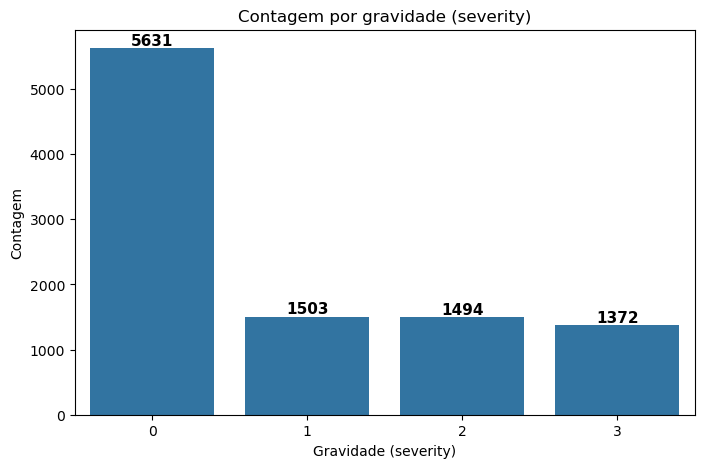

In [173]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns



plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_10k, x="severity")
plt.title("Contagem por gravidade (severity)")
plt.xlabel("Gravidade (severity)")
plt.ylabel("Contagem")

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()

## Anotação de 50000 amostras

In [174]:
import pandas as pd

# Lê o arquivo DepreRedditBR.csv em chunks e gera uma amostra aleatória de 100 instâncias
#csv_file = "DepreRedditBR.csv"
chunksize = 1000  # tamanho razoável para chunk; ajuste conforme necessário
sample_size = 50000

chunks = pd.read_csv(csv_file, chunksize=chunksize, encoding="utf-8")
sampled_chunks = []

for chunk in chunks:
    # Seleciona do chunk uma fração necessária para formar a amostra total
    # (isso minimiza carregar tudo na memória!)
    sampled = chunk.sample(
        n=min(sample_size, len(chunk)), random_state=42
    )
    sampled_chunks.append(sampled)
    # Se já coletamos mais de 100, podemos parar
    if sum(len(df) for df in sampled_chunks) >= sample_size:
        break

# Concatena as amostras e tira uma amostra final de 100, garantindo aleatoriedade
sample_df = pd.concat(sampled_chunks, ignore_index=True).sample(n=sample_size, random_state=42)
sample_df.reset_index(drop=True, inplace=True)

# sample_df agora contém 100 instâncias aleatórias do arquivo
sample_df

,text
0,"Queria mostrar uma visão diferente. OP, primei..."
1,"Garoto, eu prefiro mil vezes um pau de 14 cm d..."
2,Tenho muitas dores de cabeça que são recorrent...
3,N sou bom com conselho...Ent só queria lembrar...
4,"Bom trabalho, elsecretodesusojos. Bom trabalho..."
...,...
49995,"Sei la, não me sinto mto intimidada pq não dei..."
49996,"Se vc gosta, só vai. Eu gosto muito de caminah..."
49997,No final o que importa é sua saúde mental mano...
49998,"Pô, vou mandar a real aqui: sou bi, ultimament..."


In [ ]:
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
# Se não tiver tqdm instalado, rode: pip install tqdm
from tqdm import tqdm 

# --- Configurações ---
LIMIT_SAMPLES = 50000
MAX_WORKERS = 10  # Cuidado: Se o modelo rodar na GPU local, diminua para 2 ou 4 para não estourar a VRAM

print(f"Preparando para processar {LIMIT_SAMPLES} amostras em paralelo...")

# 1. Cria o subset (Isolamento de dados)

# 2. Função de processamento (Corrigida)
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_gpt = juri_modelos["gpt4o_mini"]
gpt4o_mini = compiled_classifiers_jury["gpt4o_mini"]


def process_row(text):
    with dspy.context(lm=lm_gpt):
        out = gpt4o_mini(text=text)
    # CORREÇÃO: Mudei 'output.probability' para 'out.probability'
    return out.severity, out.rationale, out.probability


# 3. Execução Paralela (ThreadPoolExecutor)
# ThreadPool funciona perfeitamente no Windows 11 e não exige o bloco 'if __name__ == "__main__":'
results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Usamos tqdm para mostrar uma barra de progresso no terminal do Cursor
    # O list() força a execução imediata do iterador
    results = list(tqdm(
        executor.map(process_row, sample_df['text'].tolist()), 
        total=LIMIT_SAMPLES, 
        desc="Processando"
    ))

# zip(*results) transpoe a lista de tuplas para 3 tuplas de listas
print("Desempacotando resultados...")
sample_df['severity'], sample_df['rationale'], sample_df['probs'] = zip(*results)


# 5. Salvar
#sample_df.to_csv('DepreRedditBR_parallel_50k.csv', index=False)
print("Concluído e salvo!")

In [175]:
df_50k = pd.read_csv("DepreRedditBR_parallel_50k.csv")
df_50k

,text,severity,rationale,probs
0,"Queria mostrar uma visão diferente. OP, primei...",0,O autor demonstra uma perspectiva saudável sob...,"[0.9, 0.05, 0.03, 0.02]"
1,"Garoto, eu prefiro mil vezes um pau de 14 cm d...",0,O autor demonstra uma visão clara e positiva s...,"[0.95, 0.05, 0.0, 0.0]"
2,Tenho muitas dores de cabeça que são recorrent...,0,Embora o autor tenha um diagnóstico de ansieda...,"[0.7, 0.2, 0.1, 0.0]"
3,N sou bom com conselho...Ent só queria lembrar...,0,"A falta de sintomas de depressão ou ansiedade,...","[0.9, 0.05, 0.03, 0.02]"
4,"Bom trabalho, elsecretodesusojos. Bom trabalho...",0,A ausência de qualquer sintoma de depressão ou...,"[1.0, 0.0, 0.0, 0.0]"
...,...,...,...,...
49995,"Sei la, não me sinto mto intimidada pq não dei...",0,"A falta de sintomas de depressão ou ansiedade,...","[0.9, 0.05, 0.03, 0.02]"
49996,"Se vc gosta, só vai. Eu gosto muito de caminah...",0,O autor demonstra uma atitude saudável em rela...,"[0.9, 0.05, 0.03, 0.02]"
49997,No final o que importa é sua saúde mental mano...,0,O autor demonstra uma atitude saudável em rela...,"[0.9, 0.05, 0.03, 0.02]"
49998,"Pô, vou mandar a real aqui: sou bi, ultimament...",0,"Embora o autor sinta solidão e frustração, a a...","[0.7, 0.2, 0.1, 0.0]"


In [ ]:
#df_50k['probs'] = df_50k['probs'].apply(parse_probs)
#df_50k

In [176]:
df_50k.severity.value_counts()

severity
0    42033
1     2980
2     2703
3     2284
Name: count, dtype: int64

In [177]:
df_50k.severity.value_counts(normalize=True).mul(100).round(2)

severity
0    84.07
1     5.96
2     5.41
3     4.57
Name: proportion, dtype: float64

In [178]:
value_counts = df_50k.severity.value_counts().sort_index()
percentages = df_50k.severity.value_counts(normalize=True).sort_index() * 100

for severity, count in value_counts.items():
    percent = percentages[severity]
    print(f"Severity {severity}: {count} amostras ({percent:.2f}%)")

Severity 0: 42033 amostras (84.07%)
Severity 1: 2980 amostras (5.96%)
Severity 2: 2703 amostras (5.41%)
Severity 3: 2284 amostras (4.57%)


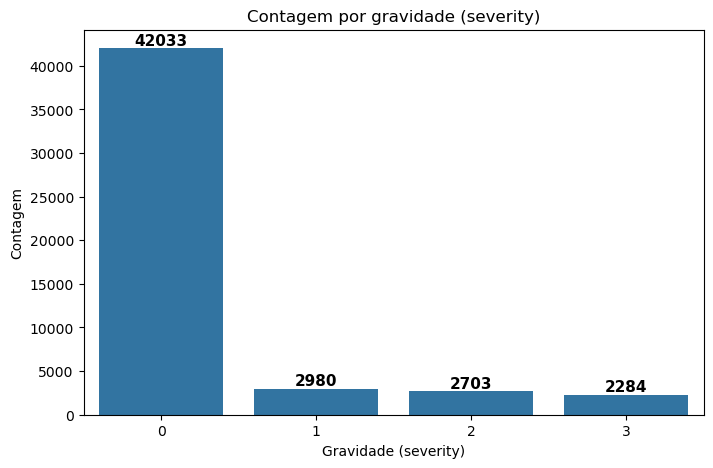

In [179]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns



plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_50k, x="severity")
plt.title("Contagem por gravidade (severity)")
plt.xlabel("Gravidade (severity)")
plt.ylabel("Contagem")

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()

In [180]:
tail = df_50k.tail().to_dict()
tail

{'text': {49995: 'Sei la, não me sinto mto intimidada pq não deixo ela perceber que tô afim, só um tempo depois que eu vou demonstrando…A princípio, eu chego de boa falando alguma coisa engraçada, leve e sempre cola. Vou criar um exemplo: “oi, vc gosta de vinagrete?”  “vc tem cara que gosta de brigadeiro de caju com maracujá, já experimentou? Não? Eu também não, inventei agora…” e assim vai. Sempre chego despretenciosa falando alguma coisa nada a ver. Um date de tempos atrás arranjei pq comecei a perguntar aonde ela tinha comprado a bicicleta dela. Chegar com o intuito de se divertir e flui naturalmente',
  49996: 'Se vc gosta, só vai. Eu gosto muito de caminahr por aí, apreciar a cidade e tudo mais, e sempre vou sozinho, ouvindo musica ou podcast nos fones. Fazer algo sozinho é libertador',
  49997: 'No final o que importa é sua saúde mental mano ! Sou programador e felizmente eu tenho um horário bom e um trampo bom, é bem flexível, as vezes as pessoas realmente que a grana é só o que

In [181]:
head = df_50k.head(10).to_dict()
head

{'text': {0: 'Queria mostrar uma visão diferente. OP, primeiro você precisa entender bem as premissas. E digo isso já dizendo que concordo com sua visão de redes sociais e o trash que são. Mas, a sua abordagem é não LIGO para postagem em redes sociais ou não QUERO postagem em rede social?Tem uma diferença bem sutil entre as duas.. na primeira, te ofereço o seguinte insight: Se realmente não ligo para redes sociais e para o que as pessoas pensarão de mim e, se eu fizer meu perfil nas redes sociais de determinada forma, ainda que boba, vai agradar a pessoa que eu amo, logo vale a pena a pagar o preço de 0 para agradar a parceira porque ao que parece isso tem um peso >0 para ela.Agora, se o caso for de você realmente VALORAR rede social, de modo que um perfil sem postagens seja o perfil que você quer ostentar na rede, realmente você deverá pesar o quanto isso é importante para você.Se vale uma opinião pessoal, pelo que demonstrou na descrição já da para perceber que tem uma ciência boa de

## Anotação de 100 amostras com os 7 modelos compilados (para comparação)

In [57]:
# Amostragem para manter o índice original e salvá-lo como coluna

import pandas as pd

# Lê o arquivo DepreRedditBR.csv mantendo o índice original como uma coluna
csv_file = "DepreRedditBR.csv"
chunksize = 1000
sample_size = 100

chunks = pd.read_csv(csv_file, chunksize=chunksize, encoding="utf-8")
sampled_chunks = []

for chunk in chunks:
    # Salva o índice original como coluna auxiliar se ainda não existir
    if "__original_index__" not in chunk.columns:
        chunk = chunk.reset_index().rename(columns={"index": "__original_index__"})
    sampled = chunk.sample(
        n=min(sample_size, len(chunk)), random_state=42
    )
    sampled_chunks.append(sampled)
    if sum(len(df) for df in sampled_chunks) >= sample_size:
        break

# Concatena as amostras e tira uma amostra final de 100, garantindo aleatoriedade
sample_df = pd.concat(sampled_chunks, ignore_index=True).sample(n=sample_size, random_state=42)
sample_df.reset_index(drop=True, inplace=True)

# Renomeia a coluna de índice original para "original_index"
if "__original_index__" in sample_df.columns:
    sample_df.rename(columns={"__original_index__": "original_index"}, inplace=True)

# sample_df agora contém 100 instâncias aleatórias com o índice original do arquivo fonte
sample_df


,original_index,text
0,67,Boa tarde pessoal.Estou fazendo este post aqui...
1,578,Moro com a minha mãe e ela é tudo que eu tenho...
2,107,Vocês demonstram afeto em publico quando estão...
3,277,Acabei de ver que um mercado que vou toda sema...
4,299,O título é auto-explicativo. E é isso kkkkkk t...
...,...,...
95,296,É o que falei no último post sobre a série. Te...
96,493,"Oi, basicamente sou um garoto com dúvidas sobr..."
97,938,"De uns tempos pra cá, eu notei como minhas cri..."
98,522,tenho 15 anos e hoje me encontrei com meu namo...


In [58]:
sample_df.to_csv("amostra_100_indices_originais.csv", index=False)

Anotação de 100 amostras com todos os modelos

In [59]:
import pandas as pd

# Lê o arquivo DepreRedditBR.csv em chunks e gera uma amostra aleatória de 100 instâncias
csv_file = "DepreRedditBR.csv"
chunksize = 1000  # tamanho razoável para chunk; ajuste conforme necessário
sample_size = 100

chunks = pd.read_csv(csv_file, chunksize=chunksize, encoding="utf-8")
sampled_chunks = []

for chunk in chunks:
    # Seleciona do chunk uma fração necessária para formar a amostra total
    # (isso minimiza carregar tudo na memória!)
    sampled = chunk.sample(
        n=min(sample_size, len(chunk)), random_state=42
    )
    sampled_chunks.append(sampled)
    # Se já coletamos mais de 100, podemos parar
    if sum(len(df) for df in sampled_chunks) >= sample_size:
        break

# Concatena as amostras e tira uma amostra final de 100, garantindo aleatoriedade
sample_df = pd.concat(sampled_chunks, ignore_index=True).sample(n=sample_size, random_state=42)
sample_df.reset_index(drop=True, inplace=True)

# sample_df agora contém 100 instâncias aleatórias do arquivo
sample_df

,text
0,Boa tarde pessoal.Estou fazendo este post aqui...
1,Moro com a minha mãe e ela é tudo que eu tenho...
2,Vocês demonstram afeto em publico quando estão...
3,Acabei de ver que um mercado que vou toda sema...
4,O título é auto-explicativo. E é isso kkkkkk t...
...,...
95,É o que falei no último post sobre a série. Te...
96,"Oi, basicamente sou um garoto com dúvidas sobr..."
97,"De uns tempos pra cá, eu notei como minhas cri..."
98,tenho 15 anos e hoje me encontrei com meu namo...


In [60]:
# Aplica o compiled_classifier a todas as instâncias de sample_df
# e armazena os Output Fields nas colunas 'severity', 'rationale' e 'prob'

# Extrai e instancia o modelo nemotron_12b do dicionário compiled_classifiers_jury
nemotron_12b = compiled_classifiers_jury["nemotron_12b"]
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_nemotron = juri_modelos["nemotron_12b"]

# Cria listas para armazenar os outputs
severities = []
rationales = []
probs = []

# Usa dspy.context para garantir que o modelo correto seja usado
with dspy.context(lm=lm_nemotron):
    for _, row in sample_df.iterrows():
        # Supondo que todas as instâncias inputam o campo 'text' para o classifier
        output = nemotron_12b(text=row['text'])
        # Os Output Fields esperados: severity, rationale, prob
        severities.append(output.severity)


# Adiciona as colunas ao dataframe
sample_df['severity'] = severities


# sample_df agora tem as colunas 'severity', 'rationale' e 'prob' geradas pelo classificador
sample_df

2026/03/11 16:02:05 WARNING dspy.clients.lm: LM response was truncated due to exceeding max_tokens=2000. You can inspect the latest LM interactions with `dspy.inspect_history()`. To avoid truncation, consider passing a larger max_tokens when setting up dspy.LM. You may also consider increasing the temperature (currently 0.0)  if the reason for truncation is repetition.


,text,severity
0,Boa tarde pessoal.Estou fazendo este post aqui...,3
1,Moro com a minha mãe e ela é tudo que eu tenho...,3
2,Vocês demonstram afeto em publico quando estão...,moderada
3,Acabei de ver que um mercado que vou toda sema...,0
4,O título é auto-explicativo. E é isso kkkkkk t...,0
...,...,...
95,É o que falei no último post sobre a série. Te...,0
96,"Oi, basicamente sou um garoto com dúvidas sobr...",1
97,"De uns tempos pra cá, eu notei como minhas cri...",3
98,tenho 15 anos e hoje me encontrei com meu namo...,0


In [61]:
#sample_df.to_csv("amostra_100_nemotron_12b_compiled.csv", index=False)

In [ ]:
# Aplica o compiled_classifier a todas as instâncias de sample_df
# e armazena os Output Fields nas colunas 'severity', 'rationale' e 'prob'

# Extrai e instancia o modelo nemotron_12b do dicionário compiled_classifiers_jury
mimo_v2_flash = compiled_classifiers_jury["mimo_v2_flash"]
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_mimo = juri_modelos["mimo_v2_flash"]

# Cria listas para armazenar os outputs
severities = []
rationales = []
probs = []

# Usa dspy.context para garantir que o modelo correto seja usado
with dspy.context(lm=lm_mimo):
    for _, row in sample_df.iterrows():
        # Supondo que todas as instâncias inputam o campo 'text' para o classifier
        output = mimo_v2_flash(text=row['text'])
        # Os Output Fields esperados: severity, rationale, prob
        severities.append(output.severity)


# Adiciona as colunas ao dataframe
sample_df['severity'] = severities

# sample_df agora tem as colunas 'severity', 'rationale' e 'prob' geradas pelo classificador
sample_df

In [ ]:
#sample_df.to_csv("amostra_100_mimo_v2_flash_compiled.csv", index=False)

In [ ]:
# Extrai e instancia o modelo nemotron_12b do dicionário compiled_classifiers_jury
deepseek_r1  = compiled_classifiers_jury["deepseek_r1"]
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_deepseek = juri_modelos["deepseek_r1"]

# Cria listas para armazenar os outputs
severities = []
rationales = []
probs = []

# Usa dspy.context para garantir que o modelo correto seja usado
with dspy.context(lm=lm_deepseek):
    for _, row in sample_df.iterrows():
        # Supondo que todas as instâncias inputam o campo 'text' para o classifier
        output = deepseek_r1(text=row['text'])
        # Os Output Fields esperados: severity, rationale, prob
        severities.append(output.severity)


# Adiciona as colunas ao dataframe
sample_df['severity'] = severities


# sample_df agora tem as colunas 'severity', 'rationale' e 'prob' geradas pelo classificador
sample_df

In [ ]:
#sample_df.to_csv("amostra_100_deepseek_r1_compiled.csv", index=False)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Adapte o countplot para usar o parâmetro 'hue', conforme orientação do warning.

ax = sns.countplot(x='severity', hue='severity', data=sample_df, palette='viridis', order=[0, 1, 2, 3], legend=False)
plt.title('Distribuição dos níveis de severidade')
x_labels = ['Ausente', 'Leve', 'Moderada', 'Severa']
plt.xticks(range(4), x_labels)
plt.xlabel('Severidade')
plt.ylabel('Contagem')

# Adiciona os valores sobre as barras
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:  # não escrever zero sobre barras ausentes
        ax.annotate(f'{height}', 
                    (p.get_x() + p.get_width() / 2, height), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()


In [ ]:
import pandas as pd

# Lê o arquivo DepreRedditBR.csv em chunks e gera uma amostra aleatória de 100 instâncias
csv_file = "DepreRedditBR.csv"
chunksize = 1000  # tamanho razoável para chunk; ajuste conforme necessário
sample_size = 100

chunks = pd.read_csv(csv_file, chunksize=chunksize, encoding="utf-8")
sampled_chunks = []

for chunk in chunks:
    # Seleciona do chunk uma fração necessária para formar a amostra total
    # (isso minimiza carregar tudo na memória!)
    sampled = chunk.sample(
        n=min(sample_size, len(chunk)), random_state=42
    )
    sampled_chunks.append(sampled)
    # Se já coletamos mais de 100, podemos parar
    if sum(len(df) for df in sampled_chunks) >= sample_size:
        break

# Concatena as amostras e tira uma amostra final de 100, garantindo aleatoriedade
sample_df = pd.concat(sampled_chunks, ignore_index=True).sample(n=sample_size, random_state=42)
sample_df.reset_index(drop=True, inplace=True)

# sample_df agora contém 100 instâncias aleatórias do arquivo
sample_df

In [ ]:
# Aplica o compiled_classifier a todas as instâncias de sample_df
# e armazena os Output Fields nas colunas 'severity', 'rationale' e 'prob'

# Extrai e instancia o modelo claude_haiku do dicionário compiled_classifiers_jury
claude_haiku = compiled_classifiers_jury["claude_haiku"]
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_claude = juri_modelos["claude_haiku"]

# Cria listas para armazenar os outputs
severities = []
rationales = []
probs = []

# Usa dspy.context para garantir que o modelo correto seja usado
with dspy.context(lm=lm_claude):
    for _, row in sample_df.iterrows():
        # Supondo que todas as instâncias inputam o campo 'text' para o classifier
        output = claude_haiku(text=row['text'])
        # Os Output Fields esperados: severity, rationale, prob
        severities.append(output.severity)
        rationales.append(output.rationale)
        probs.append(output.probability)

# Adiciona as colunas ao dataframe
sample_df['severity'] = severities
sample_df['rationale'] = rationales
sample_df['probs'] = probs

# sample_df agora tem as colunas 'severity', 'rationale' e 'prob' geradas pelo classificador
sample_df

In [ ]:
#sample_df.to_csv("amostra_100_claude_haiku_compiled.csv", index=False)

In [ ]:
import pandas as pd

# Lê o arquivo DepreRedditBR.csv em chunks e gera uma amostra aleatória de 100 instâncias
csv_file = "DepreRedditBR.csv"
chunksize = 1000  # tamanho razoável para chunk; ajuste conforme necessário
sample_size = 100

chunks = pd.read_csv(csv_file, chunksize=chunksize, encoding="utf-8")
sampled_chunks = []

for chunk in chunks:
    # Seleciona do chunk uma fração necessária para formar a amostra total
    # (isso minimiza carregar tudo na memória!)
    sampled = chunk.sample(
        n=min(sample_size, len(chunk)), random_state=42
    )
    sampled_chunks.append(sampled)
    # Se já coletamos mais de 100, podemos parar
    if sum(len(df) for df in sampled_chunks) >= sample_size:
        break

# Concatena as amostras e tira uma amostra final de 100, garantindo aleatoriedade
sample_df = pd.concat(sampled_chunks, ignore_index=True).sample(n=sample_size, random_state=42)
sample_df.reset_index(drop=True, inplace=True)

# sample_df agora contém 100 instâncias aleatórias do arquivo
sample_df

In [ ]:
# Aplica o compiled_classifier a todas as instâncias de sample_df
# e armazena os Output Fields nas colunas 'severity', 'rationale' e 'prob'

# Extrai e instancia o modelo Qwen3 30B do dicionário compiled_classifiers_jury
qwen3_30b = compiled_classifiers_jury["qwen3_30b"]
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_qwen = juri_modelos["qwen3_30b"]

# Cria listas para armazenar os outputs
severities = []
rationales = []
probs = []

# Usa dspy.context para garantir que o modelo correto seja usado
with dspy.context(lm=lm_qwen):
    for _, row in sample_df.iterrows():
        # Supondo que todas as instâncias inputam o campo 'text' para o classifier
        output = qwen3_30b(text=row['text'])
        # Os Output Fields esperados: severity, rationale, prob
        severities.append(output.severity)
        rationales.append(output.rationale)
        probs.append(output.probability)

# Adiciona as colunas ao dataframe
sample_df['severity'] = severities
sample_df['rationale'] = rationales
sample_df['probs'] = probs

# sample_df agora tem as colunas 'severity', 'rationale' e 'prob' geradas pelo classificador
sample_df

In [ ]:
#sample_df.to_csv("amostra_100_qwen3_30b_compiled.csv", index=False)

### Candidatos ao Juri de Anotadores (teste)

In [34]:
import pandas as pd

# Carrega os arquivos CSV
gpt_df = pd.read_csv("amostra_100_gpt4o-mini_compiled.csv")
c_df = pd.read_csv("amostra_100_claude_haiku_compiled.csv")
n_df = pd.read_csv("amostra_100_nemotron_12b_compiled.csv")
q_df = pd.read_csv("amostra_100_qwen3_30b_compiled.csv")
m_df = pd.read_csv("amostra_100_mimo_v2_flash_compiled.csv")
d_df = pd.read_csv("amostra_100_deepseek_r1_compiled.csv")
a_df = pd.read_csv("amostra_100_arcee_trinty_compiled.csv")

# Adiciona os prefixos nas colunas severity de cada dataframe
gpt_df = gpt_df.rename(columns={'severity': 'GPT_severity'})
c_df = c_df.rename(columns={'severity': 'C_severity'})
n_df = n_df.rename(columns={'severity': 'N_severity'})
q_df = q_df.rename(columns={'severity': 'Q_severity'})
m_df = m_df.rename(columns={'severity': 'M_severity'})
d_df = d_df.rename(columns={'severity': 'D_severity'})
a_df = a_df.rename(columns={'severity': 'A_severity'})

# Faz o merge pela coluna 'text'
jury_df = gpt_df[['text', 'GPT_severity']].merge(
    c_df[['text', 'C_severity']], on='text'
).merge(
    n_df[['text', 'N_severity']], on='text'
).merge(
    q_df[['text', 'Q_severity']], on='text'
).merge(
    m_df[['text', 'M_severity']], on='text'
).merge(
    d_df[['text', 'D_severity']], on='text'
).merge(
    a_df[['text', 'A_severity']], on='text'
)

jury_df


,text,GPT_severity,C_severity,N_severity,Q_severity,M_severity,D_severity,A_severity
0,Boa tarde pessoal.Estou fazendo este post aqui...,2,2,2,1,2,2,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,1,2,1,1,1,2,2
2,Vocês demonstram afeto em publico quando estão...,0,0,0,1,0,0,0
3,Acabei de ver que um mercado que vou toda sema...,0,0,0,0,0,0,0
4,O título é auto-explicativo. E é isso kkkkkk t...,1,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...
95,É o que falei no último post sobre a série. Te...,0,1,0,1,0,0,0
96,"Oi, basicamente sou um garoto com dúvidas sobr...",0,0,0,0,0,0,0
97,"De uns tempos pra cá, eu notei como minhas cri...",3,3,3,3,3,3,3
98,tenho 15 anos e hoje me encontrei com meu namo...,0,0,1,1,0,0,0


In [35]:
jury_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   text          100 non-null    object
 1   GPT_severity  100 non-null    int64 
 2   C_severity    100 non-null    int64 
 3   N_severity    100 non-null    int64 
 4   Q_severity    100 non-null    int64 
 5   M_severity    100 non-null    int64 
 6   D_severity    100 non-null    int64 
 7   A_severity    100 non-null    int64 
dtypes: int64(7), object(1)
memory usage: 6.4+ KB


In [36]:
#jury_df.to_csv("jury_df_100_samples.csv", index=False)

In [37]:
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix

# Definição dos modelos e nomes para exibição
comparisons = [
    ('Claude', c_df['C_severity']),
    ('Nemotron', n_df['N_severity']),
    ('Qwen3', q_df['Q_severity']),
    ('Mimo', m_df['M_severity']),
    ('Deepseek', d_df['D_severity']),
    ('Arcee', a_df['A_severity'])
]

y_true = gpt_df['GPT_severity']

for model_name, y_pred in comparisons:
    print(f"\n==== Comparação: {model_name} vs GPT-4o ====")
    y_true_clean = []
    y_pred_clean = []
    # Exclui casos em que há valores nan ou não numéricos, se houver
    for yt, yp in zip(y_true, y_pred):
        try:
            if not pd.isna(yp) and not pd.isna(yt):
                yt_int = int(yt)
                yp_int = int(yp)
                if yp_int != 99:
                    y_true_clean.append(yt_int)
                    y_pred_clean.append(yp_int)
        except:
            continue  # pula se casting falhar por qualquer motivo

    labels = [0, 1, 2, 3]
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_clean, y_pred_clean, labels=labels))
    print("\nClassification Report:")
    print(classification_report(y_true_clean, y_pred_clean, labels=labels))
    print(f"QWK (Kappa Ponderado): {cohen_kappa_score(y_true_clean, y_pred_clean, weights='quadratic')} ")
    print(f"F1 Macro: {f1_score(y_true_clean, y_pred_clean, average='macro', zero_division=0)}")
    print(f"F1 Ponderado: {f1_score(y_true_clean, y_pred_clean, average='weighted', zero_division=0)}")



==== Comparação: Claude vs GPT-4o ====
Confusion Matrix:
[[38 11  1  0]
 [ 0  7  9  0]
 [ 0  0 10  0]
 [ 0  0  2 22]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.76      0.86        50
           1       0.39      0.44      0.41        16
           2       0.45      1.00      0.62        10
           3       1.00      0.92      0.96        24

    accuracy                           0.77       100
   macro avg       0.71      0.78      0.71       100
weighted avg       0.85      0.77      0.79       100

QWK (Kappa Ponderado): 0.9131944444444444 
F1 Macro: 0.7142307021622878
F1 Ponderado: 0.7897657521506626

==== Comparação: Nemotron vs GPT-4o ====
Confusion Matrix:
[[45  5  0  0]
 [ 0 12  4  0]
 [ 0  0  8  2]
 [ 0  0  2 22]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        50
           1       0.71      0.75      0.73        16
         

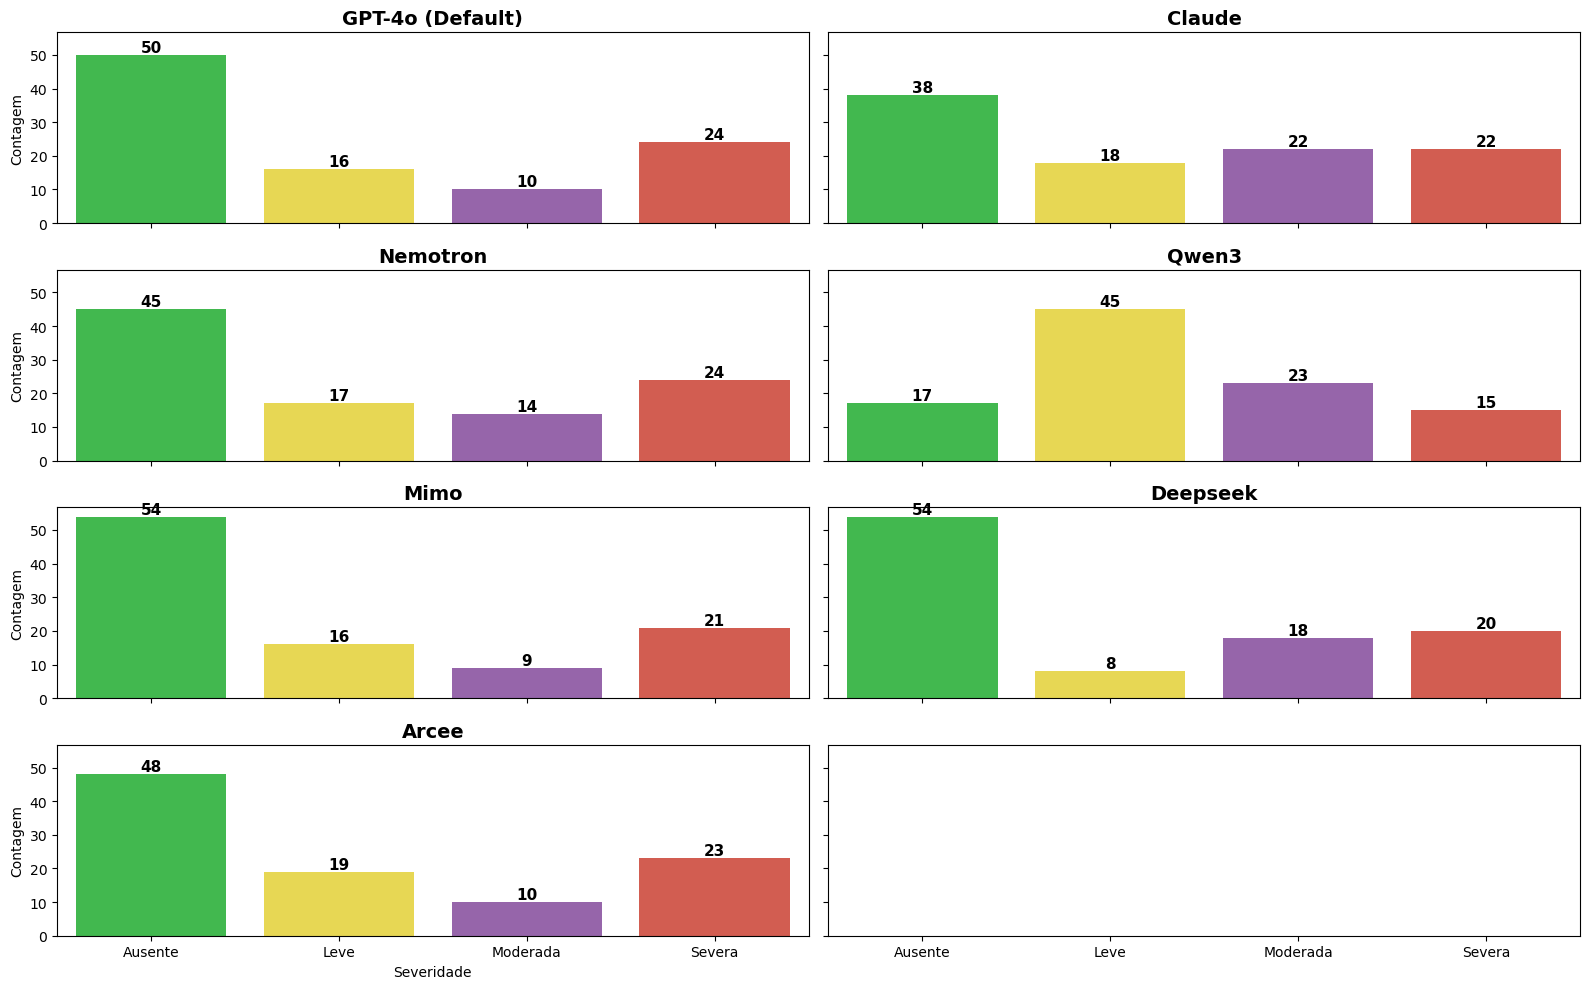

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map para nomes legíveis
model_titles = {
    'gpt_df': 'GPT-4o (Default)',
    'c_df': 'Claude',
    'n_df': 'Nemotron',
    'q_df': 'Qwen3',
    'm_df': 'Mimo',
    'd_df': 'Deepseek',
    'a_df': 'Arcee'
}

custom_palette = {
    0: '#2ecc40',   # Verde
    1: '#FFEB3B',   # Amarelo
    2: '#9B59B6',   # Roxo
    3: '#E74C3C'    # Vermelho
}

dfs = [gpt_df, c_df, n_df, q_df, m_df, d_df, a_df]
titles = [model_titles['gpt_df'], model_titles['c_df'], model_titles['n_df'], model_titles['q_df'], model_titles['m_df'], model_titles['d_df'], model_titles['a_df']]
colunas = ['GPT_severity', 'C_severity', 'N_severity', 'Q_severity', 'M_severity', 'D_severity', 'A_severity']

fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex=True, sharey=True)

for i, (df, coluna, title) in enumerate(zip(dfs, colunas, titles)):
    ax = axes[i//2, i%2]
    # Conta a ocorrência de cada valor de severidade (0-3)
    if coluna not in df.columns:
        # Consistência: às vezes os dfs têm apenas 'severity'
        col_to_use = 'severity'
    else:
        col_to_use = coluna
    sns.countplot(
        x=col_to_use, 
        hue=col_to_use,
        data=df, 
        palette=custom_palette, 
        order=[0, 1, 2, 3], 
        legend=False,
        ax=ax
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Severidade')
    if i % 2 == 0:
        ax.set_ylabel('Contagem')
    else:
        ax.set_ylabel("")
    x_labels = ['Ausente', 'Leve', 'Moderada', 'Severa']
    ax.set_xticks(range(4))
    ax.set_xticklabels(x_labels)
    # Adiciona os valores sobre as barras
    for p in ax.patches:
        height = int(p.get_height())
        if height > 0:
            ax.annotate(f'{height}', 
                        (p.get_x() + p.get_width() / 2, height), 
                        ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [40]:


correl_df = pd.DataFrame({
    'GPT': gpt_df['severity'] if 'severity' in gpt_df.columns else gpt_df['GPT_severity'],
    'Claude': c_df['severity'] if 'severity' in c_df.columns else c_df['C_severity'],
    'Nemotron': n_df['severity'] if 'severity' in n_df.columns else n_df['N_severity'],
    'Qwen': q_df['severity'] if 'severity' in q_df.columns else q_df['Q_severity'],
    'Mimo': m_df['severity'] if 'severity' in m_df.columns else m_df['M_severity'],
    'Deepseek': d_df['severity'] if 'severity' in d_df.columns else d_df['D_severity'],
    'Arcee': a_df['severity'] if 'severity' in a_df.columns else a_df['A_severity']
})

correl_matrix = correl_df.corr()
print("Matriz de correlação entre os modelos:")
print(correl_matrix)


Matriz de correlação entre os modelos:
               GPT    Claude  Nemotron      Qwen      Mimo  Deepseek     Arcee
GPT       1.000000  0.926782  0.960408  0.792182  0.934894  0.876880  0.934547
Claude    0.926782  1.000000  0.919371  0.777898  0.883931  0.835463  0.896833
Nemotron  0.960408  0.919371  1.000000  0.781133  0.906498  0.864090  0.899895
Qwen      0.792182  0.777898  0.781133  1.000000  0.778919  0.709455  0.755314
Mimo      0.934894  0.883931  0.906498  0.778919  1.000000  0.897997  0.919733
Deepseek  0.876880  0.835463  0.864090  0.709455  0.897997  1.000000  0.881039
Arcee     0.934547  0.896833  0.899895  0.755314  0.919733  0.881039  1.000000


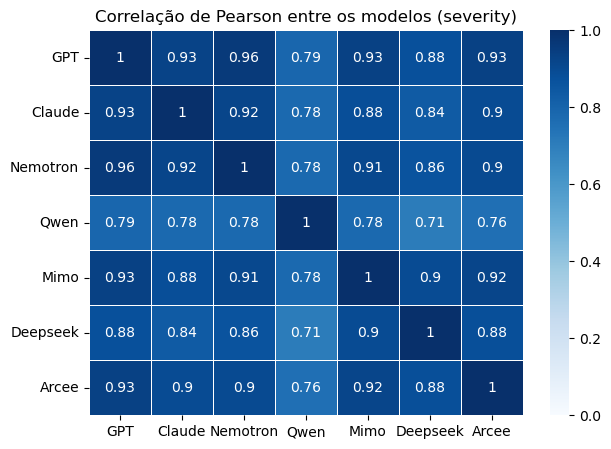

In [42]:
# A métrica apresentada no gráfico abaixo é o coeficiente de correlação de Pearson. 
# Essa métrica mede a força e a direção da relação linear entre as notas de severidade atribuídas pelos diferentes modelos LLM (como GPT, Claude, Nemotron, Qwen, etc).
# O valor do coeficiente pode variar de 0 (nenhuma correlação) a 1 (correlação perfeita), sendo que valores mais altos indicam que dois modelos costumam dar avaliações semelhantes de severidade para os mesmos textos.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.heatmap(correl_matrix, annot=True, cmap='Blues', vmin=0, vmax=1, linewidths=0.5)
plt.title('Correlação de Pearson entre os modelos (severity)')
plt.show()


Teste de Merge dos Datasets anotados

In [43]:
df_100 = pd.read_csv("amostra_100_indices_originais.csv")
df_5k = pd.read_csv('DepreRedditBR_parallel_5k_0.csv')
df_10k = pd.read_csv('DepreRedditBR_parallel_10k.csv')
df_50k = pd.read_csv('DepreRedditBR_parallel_50k.csv')


In [44]:
# Entre 5k e 10k
inter_5k_10k = df_5k[df_5k['text'].isin(df_10k['text'])]
inter_5k_10k

,text,severity,rationale,probs
0,"Parece que ninguem quer ficar perto de mim, e,...",2,"Os sentimentos de inadequação, a dor causada p...","[0.0, 0.3, 0.5, 0.2]"
1,"Eu sou deprimido, porem tem períodos que fico ...",2,"Os sintomas descritos, como o sentimento de va...","[0.0, 0.2, 0.5, 0.3]"
2,"Boa tarde. Bem, é basicamente um desabafo. A v...",3,"Os sintomas descritos, como a sensação de esta...","[0.0, 0.1, 0.4, 0.5]"
3,"Me tirem uma duvida, ser perfeccionista ao ac...",1,"Os sintomas descritos, como perfeccionismo e d...","[0.7, 0.15, 0.1, 0.05]"
4,"Oi gente, desculpa o textão, já mandei isso em...",1,Os sintomas descritos são mais indicativos de ...,"[0.7, 0.15, 0.1, 0.05]"
...,...,...,...,...
4995,Estou ficando com uma garota que conheci tem ...,0,Os sentimentos de insegurança e a preocupação ...,"[0.9, 0.05, 0.03, 0.02]"
4996,eu sou a babaca por brigar com meu namorado na...,0,A autora demonstra uma preocupação com suas aç...,"[0.9, 0.05, 0.03, 0.02]"
4997,Minha noiva (26M) e eu (24M) temos 3 anos junt...,0,O texto expressa preocupações sobre a convivên...,"[0.9, 0.05, 0.03, 0.02]"
4998,Eu (H24) ela (M19) vou chamar ela de “A” pra s...,0,Os sentimentos de frustração e insegurança exp...,"[0.7, 0.2, 0.05, 0.05]"


In [45]:
# Entre 10k e 50k
inter_10k_50k = df_10k[df_10k['text'].isin(df_50k['text'])]
inter_10k_50k

,text,severity,rationale,probs
0,Talvez possa ser útil pra alguém. Não é a verd...,0,O autor demonstra uma atitude positiva e proat...,"[0.9, 0.05, 0.03, 0.02]"
1,( Essa história vai ser longa ) Eu não ...,3,"Os sintomas de trauma, solidão, sentimentos de...","[0.0, 0.1, 0.3, 0.6]"
2,"Sim, gnt. É isso… parece fútil mas não é! Eu v...",2,Os sentimentos de tristeza profunda relacionad...,"[0.0, 0.2, 0.5, 0.3]"
3,Senta que a história é grande. Meu grupo de am...,0,Embora o autor tenha enfrentado dificuldades e...,"[0.7, 0.2, 0.1, 0.0]"
4,Estou sem vontade de continuar vivendo. De an...,3,"Os sentimentos de desesperança, aversão ao pró...","[0.0, 0.05, 0.1, 0.85]"
...,...,...,...,...
9995,Estou falando de relacionamento fechado e hete...,0,O autor demonstra uma reflexão saudável sobre ...,"[0.9, 0.05, 0.05, 0.0]"
9996,Sou uma garota e com onze anos tive minha prim...,0,A autora demonstra uma busca por compreensão e...,"[0.9, 0.05, 0.03, 0.02]"
9997,"primeiramente, sou novo aqui, criei essa conta...",3,"Os relatos de abuso físico, automutilação, e a...","[0.0, 0.05, 0.1, 0.85]"
9998,"Pô, vou mandar a real aqui: sou bi, ultimament...",0,"Embora o autor sinta solidão e frustração, a a...","[0.7, 0.2, 0.1, 0.0]"


In [46]:
# Entre 100 e 50k
inter_100_50k = df_100[df_100['text'].isin(df_50k['text'])]
inter_100_50k

,original_index,text
0,67,Boa tarde pessoal.Estou fazendo este post aqui...
1,578,Moro com a minha mãe e ela é tudo que eu tenho...
2,107,Vocês demonstram afeto em publico quando estão...
3,277,Acabei de ver que um mercado que vou toda sema...
4,299,O título é auto-explicativo. E é isso kkkkkk t...
...,...,...
95,296,É o que falei no último post sobre a série. Te...
96,493,"Oi, basicamente sou um garoto com dúvidas sobr..."
97,938,"De uns tempos pra cá, eu notei como minhas cri..."
98,522,tenho 15 anos e hoje me encontrei com meu namo...


In [47]:
# Entre 100 e 50k
inter_50k_100 = df_50k[df_50k['text'].isin(df_100['text'])]
inter_50k_100

,text,severity,rationale,probs
630,"Tenho 49 anos, sou pai solteiro assalariado e ...",3,"Os sentimentos de tédio, desânimo, solidão e a...","[0.0, 0.05, 0.1, 0.85]"
3032,É um absurdo pensamentos como esse ainda exist...,0,O autor demonstra uma forte reação emocional e...,"[0.9, 0.05, 0.05, 0.0]"
4582,"**Um pequeno desabafo, ou reflexão** Já faz m...",3,"Os sentimentos de vontade de morrer, o uso de ...","[0.0, 0.05, 0.15, 0.8]"
4650,"Oi, basicamente sou um garoto com dúvidas sobr...",0,O autor expressa sentimentos de felicidade e a...,"[0.9, 0.05, 0.03, 0.02]"
5505,Boa noite queridxs.Faz um tempo que me questio...,0,O autor demonstra uma preocupação com sua sexu...,"[0.9, 0.05, 0.03, 0.02]"
...,...,...,...,...
46987,"Olá, sou uma mulher lesbica tenho 20 anos ee q...",0,A autora demonstra uma reflexão saudável sobre...,"[0.9, 0.05, 0.03, 0.02]"
48535,É o que falei no último post sobre a série. Te...,0,"Embora o autor expresse angústia e frustração,...","[0.7, 0.2, 0.1, 0.0]"
48900,Estou tendo problemas para ir ao colégio por c...,3,"Os sintomas de ansiedade intensa, a evitação d...","[0.0, 0.1, 0.2, 0.7]"
49067,"Sofro de ansiedade social desde a infância, ma...",0,Embora a autora tenha ansiedade social e tenha...,"[0.9, 0.05, 0.05, 0.0]"


In [48]:
# Para reordenar inter_50k_100 de acordo com a ordem da coluna 'text' em inter_100_50k:
inter_50k_100 = inter_50k_100.set_index('text').loc[inter_100_50k['text']].reset_index()
inter_50k_100

,text,severity,rationale,probs
0,Boa tarde pessoal.Estou fazendo este post aqui...,2,"Os sintomas de ansiedade, falta de energia, se...","[0.0, 0.5, 0.4, 0.1]"
1,Moro com a minha mãe e ela é tudo que eu tenho...,1,"Os sentimentos de solidão, medo de exposição e...","[0.2, 0.4, 0.3, 0.1]"
2,Vocês demonstram afeto em publico quando estão...,0,O texto não apresenta sintomas claros de depre...,"[0.9, 0.05, 0.05, 0.0]"
3,Acabei de ver que um mercado que vou toda sema...,0,Os sentimentos de decepção e frustração não sã...,"[0.9, 0.05, 0.05, 0.0]"
4,O título é auto-explicativo. E é isso kkkkkk t...,1,A referência a sentimentos de tristeza e a com...,"[0.5, 0.3, 0.15, 0.05]"
...,...,...,...,...
95,É o que falei no último post sobre a série. Te...,0,"Embora o autor expresse angústia e frustração,...","[0.7, 0.2, 0.1, 0.0]"
96,"Oi, basicamente sou um garoto com dúvidas sobr...",0,O autor expressa sentimentos de felicidade e a...,"[0.9, 0.05, 0.03, 0.02]"
97,"De uns tempos pra cá, eu notei como minhas cri...",3,"Os sintomas de ideação suicida, choro constant...","[0.0, 0.1, 0.2, 0.7]"
98,tenho 15 anos e hoje me encontrei com meu namo...,0,Embora o autor não mencione sintomas clássicos...,"[0.7, 0.2, 0.1, 0.0]"


## Configuração do juri Piloto (100 amostras)

In [62]:
#Configuração do DeepSeek R1 como organizador do júri

import dspy

dspy.configure(lm=juri_modelos["deepseek_r1"])

In [63]:
from pandas import read_csv

jury_df = read_csv("jury_df_100_samples_7_models.csv")
jury_df

,text,GPT_severity,C_severity,N_severity,Q_severity,M_severity,D_severity,A_severity
0,Boa tarde pessoal.Estou fazendo este post aqui...,2,2,2,1,2,2,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,1,2,1,1,1,2,2
2,Vocês demonstram afeto em publico quando estão...,0,0,0,1,0,0,0
3,Acabei de ver que um mercado que vou toda sema...,0,0,0,0,0,0,0
4,O título é auto-explicativo. E é isso kkkkkk t...,1,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...
95,É o que falei no último post sobre a série. Te...,0,1,0,1,0,0,0
96,"Oi, basicamente sou um garoto com dúvidas sobr...",0,0,0,0,0,0,0
97,"De uns tempos pra cá, eu notei como minhas cri...",3,3,3,3,3,3,3
98,tenho 15 anos e hoje me encontrei com meu namo...,0,0,1,1,0,0,0


In [64]:
jury_df.GPT_severity.value_counts()

GPT_severity
0    50
3    24
1    16
2    10
Name: count, dtype: int64

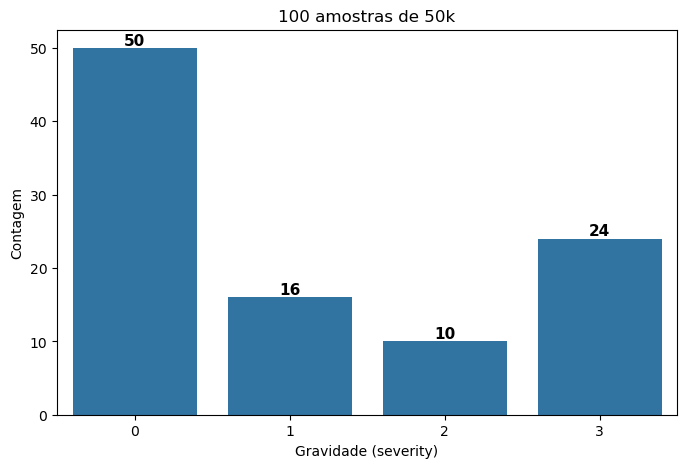

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adaptar o código para ordenar os dados de severity no eixo x de 0 a 3
order = [0, 1, 2, 3]
plt.figure(figsize=(8,5))
ax = sns.countplot(data=jury_df, x="GPT_severity", order=order)
plt.title("100 amostras de 50k")
plt.xlabel("Gravidade (severity)")
plt.ylabel("Contagem")

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()

In [66]:
jury_df.drop(columns=['Q_severity', 'D_severity'], inplace=True)
jury_df

,text,GPT_severity,C_severity,N_severity,M_severity,A_severity
0,Boa tarde pessoal.Estou fazendo este post aqui...,2,2,2,2,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,1,2,1,1,2
2,Vocês demonstram afeto em publico quando estão...,0,0,0,0,0
3,Acabei de ver que um mercado que vou toda sema...,0,0,0,0,0
4,O título é auto-explicativo. E é isso kkkkkk t...,1,1,1,0,0
...,...,...,...,...,...,...
95,É o que falei no último post sobre a série. Te...,0,1,0,0,0
96,"Oi, basicamente sou um garoto com dúvidas sobr...",0,0,0,0,0
97,"De uns tempos pra cá, eu notei como minhas cri...",3,3,3,3,3
98,tenho 15 anos e hoje me encontrei com meu namo...,0,0,1,0,0


In [67]:
class Jury_Evaluation(dspy.Signature):
    """
    Você é um Especialista Sênior em Psicometria e Linguística Clínica.
    Sua tarefa é consolidar a classificação de severidade de depressão analisando múltiplos pareceres.

    CRITÉRIOS DE DECISÃO:
      1. Se houver UNANIMIDADE (4/4) ou CONSENSO FORTE (3/4 concordam com a Principal), confirme a Principal.
      2. Se houver DIVERGÊNCIA onde 2 concordam com a Principal, confirme a Principal.    
      3. Se houver DIVERGÊNCIA maior, leia o texto com extrema atenção aos CRITÉRIOS DE DESEMPATE e considere os VETORES de CONFIANÇA de cada modelo para cada classe ao decidir.
      4. Se não se sentir seguro para decidir, separe essa amostra para avaliação humana especializada.

    CRITÉRIOS DE DESEMPATE
      - Priorize menções explícitas de ideação suicida ou autolesão como "Severa".
      - Diferencie "Leve" de "Moderado" pelo impacto funcional descrito no texto.

    VETORES DE CONFIANÇA (Pesos de Autoridade por Classe [0, 1, 2, 3]):
      - GPT-4o-mini: [0.75, 0.70, 0.75, 0.85] -> Autoridade em Leve (1) e Moderada (2).
      - Claude Haiku: [0.80, 0.50, 0.70, 1.00] -> Autoridade em Ausente (0) e Severa (3). Bom em Leve (1) e Moderada (2).
      - Nemotron 12B: [1.00, 0.35, 0.70, 1.00] -> Autoridade em Ausente e Severa (3). Bom em Moderada (2)
      - Arcee Large: [0.70, 0.35, 0.60, 1.00] ->  Autoridade em Severa (3). Auxiliar forte em Moderada (2).
      - MiMo v2 Flash: [0.75, 0.35, 0.40, 1.00] -> Auxiliar forte em Ausente (0). Autoridade em Severa (3).
    """

    # Inputs: removendo Qwen, adicionando MIMO e DeepSeek
    texto_usuario = dspy.InputField(desc="Texto original extraído do Reddit")
    label_gpt4o = dspy.InputField(desc="Avaliação do modelo principal (GPT-4o-mini)")
    label_claude = dspy.InputField(desc="Avaliação do revisor A (Claude 3.5 Haiku)")
    label_nemotron = dspy.InputField(desc="Avaliação do revisor B (Nemotron 12B)")
    label_mimo = dspy.InputField(desc="Avaliação do revisor C (MIMO v2 Flash)")    
    label_arcee = dspy.InputField(desc="Avaliação do revisor D (Arcee Large)")   

    # Outputs
    rationale = dspy.OutputField(desc="Explique se houve consenso ou conflito e por que escolheu o rótulo final.")
    label_is_confirmed = dspy.OutputField(desc="Deve ser estritamente 'True' ou 'False'")
    final_label = dspy.OutputField(desc="Classificação final: 0, 1, 2, 3")


In [68]:
class Jury_Consensus(dspy.Module):
    def __init__(self):
        super().__init__()
        # ChainOfThought ativa o modo de raciocínio passo-a-passo
        self.juiz = dspy.ChainOfThought(Jury_Evaluation)

    def forward(self, texto_usuario, label_gpt4o, label_claude, label_nemotron, label_mimo, label_arcee):
        # O forward conecta os dados de entrada à Assinatura
        return self.juiz(
            texto_usuario=texto_usuario,
            label_gpt4o=label_gpt4o,
            label_claude=label_claude,
            label_nemotron=label_nemotron,
            label_mimo=label_mimo,
            label_arcee=label_arcee
        )

In [69]:
import concurrent.futures
from tqdm import tqdm

# Obter o LM do gpt4o-mini para usar no contexto
lm_gpt = juri_modelos.get("gpt4o_mini")
if lm_gpt is None:
    raise ValueError("LM do gpt4o-mini não encontrado! Verifique se 'juri_modelos' está definido.")

jury_llm = Jury_Consensus()

# Função auxiliar para processar cada linha
def process_row(row):
    """Processa uma linha do dataframe usando o Jury_Consensus com o modelo compilado do gpt4o-mini."""
    with dspy.context(lm=lm_gpt):
        output = jury_llm(
            texto_usuario=row['text'],
            label_gpt4o=row['GPT_severity'],
            label_claude=row['C_severity'],
            label_nemotron=row['N_severity'],
            label_mimo=row['M_severity'],
            label_arcee=row['A_severity']
        )
    # Retornar todos os 3 OutputFields da Signature: rationale, label_is_confirmed, final_label
    return {
        "text": row['text'],
        "rationale": getattr(output, 'rationale', None),
        "label_is_confirmed": getattr(output, 'label_is_confirmed', None),
        "final_label": getattr(output, 'final_label', None)
    }

# Processamento paralelo com barra de progresso
with concurrent.futures.ThreadPoolExecutor() as executor:
    # Submeter todas as tarefas
    future_to_row = {executor.submit(process_row, row): i for i, (_, row) in enumerate(jury_df.iterrows())}
    results_buffer = [None] * len(future_to_row)
    
    # Processar resultados com barra de progresso usando tqdm
    for future in tqdm(concurrent.futures.as_completed(future_to_row), 
                       total=len(future_to_row), 
                       desc="Processando Jury_Consensus"):
        idx = future_to_row[future]
        try:
            result = future.result()
            results_buffer[idx] = result
        except Exception as exc:
            # Em caso de erro, criar resultado com valores None
            results_buffer[idx] = {
                "text": jury_df.iloc[idx]['text'],
                "rationale": f'Erro: {exc}',
                "label_is_confirmed": None,
                "final_label": None
            }

# Transformar resultados em dataframe com todos os campos
jury_results_df = pd.DataFrame(results_buffer)


Processando Jury_Consensus: 100%|██████████| 100/100 [00:00<00:00, 137.41it/s]


In [70]:
jury_results_df

,text,rationale,label_is_confirmed,final_label
0,Boa tarde pessoal.Estou fazendo este post aqui...,"Houve unanimidade entre todos os avaliadores, ...",True,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,"Houve uma divergência nas avaliações, com 3 do...",True,1
2,Vocês demonstram afeto em publico quando estão...,"Houve unanimidade entre todos os revisores, co...",True,0
3,Acabei de ver que um mercado que vou toda sema...,"Houve unanimidade entre todos os revisores, co...",True,0
4,O título é auto-explicativo. E é isso kkkkkk t...,Houve um consenso forte entre três dos cinco m...,True,1
...,...,...,...,...
95,É o que falei no último post sobre a série. Te...,"Houve uma divergência nas avaliações, com 4 do...",True,0
96,"Oi, basicamente sou um garoto com dúvidas sobr...","Houve unanimidade nas avaliações, com todos os...",True,0
97,"De uns tempos pra cá, eu notei como minhas cri...","Houve unanimidade entre todos os revisores, o ...",True,3
98,tenho 15 anos e hoje me encontrei com meu namo...,"Houve um consenso forte entre os modelos, com ...",True,0


In [71]:
jury_results_df.label_is_confirmed.value_counts()


label_is_confirmed
True     95
False     5
Name: count, dtype: int64

In [72]:
jury_results_df.final_label.value_counts()

final_label
0    45
3    25
1    18
2    12
Name: count, dtype: int64

In [73]:
jury_df

,text,GPT_severity,C_severity,N_severity,M_severity,A_severity
0,Boa tarde pessoal.Estou fazendo este post aqui...,2,2,2,2,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,1,2,1,1,2
2,Vocês demonstram afeto em publico quando estão...,0,0,0,0,0
3,Acabei de ver que um mercado que vou toda sema...,0,0,0,0,0
4,O título é auto-explicativo. E é isso kkkkkk t...,1,1,1,0,0
...,...,...,...,...,...,...
95,É o que falei no último post sobre a série. Te...,0,1,0,0,0
96,"Oi, basicamente sou um garoto com dúvidas sobr...",0,0,0,0,0
97,"De uns tempos pra cá, eu notei como minhas cri...",3,3,3,3,3
98,tenho 15 anos e hoje me encontrei com meu namo...,0,0,1,0,0


In [74]:
jury_results_df.head().to_dict()

{'text': {0: 'Boa tarde pessoal.Estou fazendo este post aqui pois não sinto abertura para falar disso com minha esposa.  Tenho 26 anos, sou Designer Gráfico e Digital, Gestor de Tráfego e atualmente gerencio a conta de um Youtuber no ramo cripto (isso é importante).  Bom... Tentarei ser breve.  Trabalho na minha área a 7 anos, desde a faculdade, passei por 2 agências e nunca tirei férias, sempre foram apenas alguns dias no fim do ano, e hoje eu não tenho abertura para pedir férias por ser MEI, mesmo que não fosse, a situação da empresa que presto serviços não está boa, e os possíveis patrocinadores não estão finalizando os contratos logo para recebermos o pagamento... Então não tenho abertura alguma para falar sobre férias no trabalho...Outra situação é que, como meu Chefe é Youtube do mercado cripto, sou chamado a qualquer hora do dia, dependendo do que acontece na bolsa e nas criptos, ou seja, preciso estar a disposição o dia inteiro, manhã, tarde e noite e isso me consome, pois não 

In [75]:
# Calcular a proporção de label_is_confirmed=True para cada classe de final_label (0, 1, 2, 3)
# Normalizar: final_label pode vir como int ou str; label_is_confirmed pode vir como bool ou str "True"/"False"
df = jury_results_df.copy()
df['final_label_num'] = pd.to_numeric(df['final_label'], errors='coerce')
df['confirmed'] = df['label_is_confirmed'].apply(
    lambda x: x is True or (isinstance(x, str) and x.strip().lower() == 'true')
)

proporcoes = {}
for label in [0, 1, 2, 3]:
    mask = df['final_label_num'] == label
    total = mask.sum()
    confirmados = (df.loc[mask, 'confirmed']).sum()
    proporcao = confirmados / total if total > 0 else 0.0
    proporcoes[label] = proporcao
    print(f"Classe {label}: proporção confirmada = {proporcao:.2%} ({int(confirmados)}/{int(total)})")

Classe 0: proporção confirmada = 100.00% (45/45)
Classe 1: proporção confirmada = 77.78% (14/18)
Classe 2: proporção confirmada = 91.67% (11/12)
Classe 3: proporção confirmada = 100.00% (25/25)


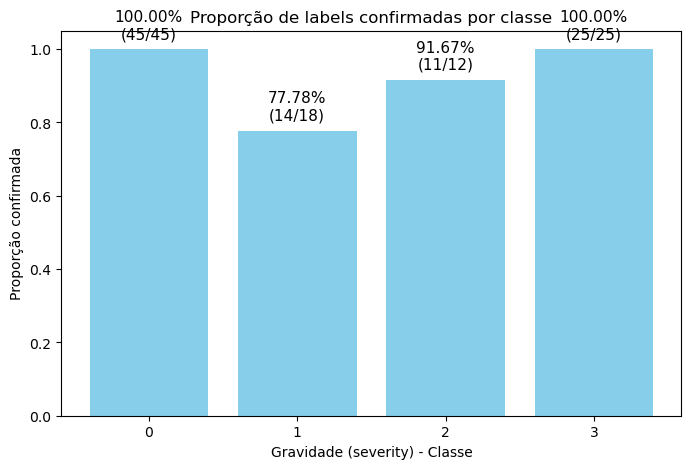

In [76]:
import matplotlib.pyplot as plt

# Criar listas para plotar
labels = list(proporcoes.keys())
proporcionais = [proporcoes[l] for l in labels]

# Extrair confirmados e totais para annotation
totais = []
confirmados = []
for label in labels:
    mask = df['final_label_num'] == label
    total = mask.sum()
    confirmado = (df.loc[mask, 'confirmed']).sum()
    totais.append(total)
    confirmados.append(confirmado)

plt.figure(figsize=(8,5))
bars = plt.bar(labels, proporcionais, color="skyblue")

plt.title("Proporção de labels confirmadas por classe")
plt.xlabel("Gravidade (severity) - Classe")
plt.ylabel("Proporção confirmada")

plt.ylim(0, 1.05)

# Adicionar anotações no topo das barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    annotation = f"{proporcionais[i]:.2%}\n({int(confirmados[i])}/{int(totais[i])})"
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             annotation, ha='center', va='bottom', fontsize=11)

plt.xticks(labels)
plt.show()


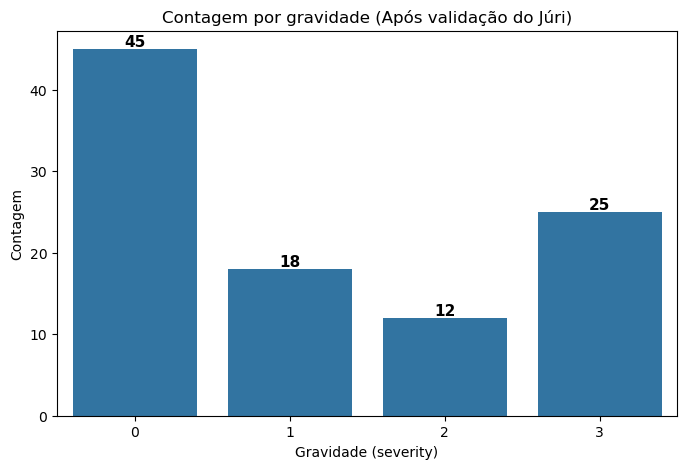

In [77]:


import matplotlib.pyplot as plt
import seaborn as sns

# Adaptar o código para ordenar os dados de severity no eixo x de 0 a 3
order = [0, 1, 2, 3]
plt.figure(figsize=(8,5))
ax = sns.countplot(data=jury_results_df, x="final_label", order=order)
plt.title("Contagem por gravidade (Após validação do Júri)")
plt.xlabel("Gravidade (severity)")
plt.ylabel("Contagem")

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()

In [78]:
#jury_results_df.to_csv('jury_results_df_100_samples.csv', index=False)

### Aplicação do Júri a uma amostra estratificada de 100 amostras

In [79]:

# Usando .sample() diretamente no groupby para evitar DeprecationWarning
# Esta é a forma recomendada e mais eficiente no pandas 2.0+
sample_per_severity = (
    df_5k.groupby('severity', group_keys=False)
    .sample(n=25, random_state=42)
    .reset_index(drop=True)
)
sample_per_severity

,text,severity,rationale,probs
0,Só queria dizer isso.,0,"A ausência de informações sobre sentimentos, p...","[0.9, 0.05, 0.03, 0.02]"
1,"Ola,me chamo Davi, não vou revelar minha idade...",0,O narrador demonstra uma luta emocional signif...,"[0.7, 0.2, 0.05, 0.05]"
2,"Eu, homão machão, vim visitar minha mãe pro fi...",0,Embora o texto aborde questões de insegurança ...,"[0.7, 0.2, 0.05, 0.05]"
3,"É isso, nem me caiu a ficha ainda. Na sétima c...",0,Os sentimentos de alívio e a motivação para re...,"[0.7, 0.15, 0.1, 0.05]"
4,Anteriormente fiz um post antes de assistir a ...,0,O autor demonstra uma consciência de suas emoç...,"[0.7, 0.2, 0.05, 0.05]"
...,...,...,...,...
95,Desde cedo eu sempre fui rejeitado e maioria d...,3,"Os sentimentos de rejeição persistente, solidã...","[0.0, 0.1, 0.3, 0.6]"
96,"Oi, não quero muita enrolação e vou direto par...",3,"Os sentimentos de culpa, a preocupação com a s...","[0.0, 0.2, 0.3, 0.5]"
97,"Fobia-social, ansiedade, pobreza, solidão, e ""...",3,"Os sintomas descritos, como dor emocional inte...","[0.0, 0.05, 0.3, 0.65]"
98,"Querido Ina. Hoje foi um dia como os outros, f...",3,"Os sentimentos de solidão intensa, a percepção...","[0.0, 0.05, 0.3, 0.65]"


In [80]:
sample_per_severity.drop(columns=['rationale', 'probs'], inplace=True)
sample_per_severity

,text,severity
0,Só queria dizer isso.,0
1,"Ola,me chamo Davi, não vou revelar minha idade...",0
2,"Eu, homão machão, vim visitar minha mãe pro fi...",0
3,"É isso, nem me caiu a ficha ainda. Na sétima c...",0
4,Anteriormente fiz um post antes de assistir a ...,0
...,...,...
95,Desde cedo eu sempre fui rejeitado e maioria d...,3
96,"Oi, não quero muita enrolação e vou direto par...",3
97,"Fobia-social, ansiedade, pobreza, solidão, e ""...",3
98,"Querido Ina. Hoje foi um dia como os outros, f...",3


In [81]:
sample_per_severity.severity.value_counts()

severity
0    25
1    25
2    25
3    25
Name: count, dtype: int64

In [ ]:
#sample_per_severity.to_csv('amostra_estratificada_100_gpt4o_mini.csv', index=False)

In [ ]:
compiled_classifiers_jury

In [ ]:
# Extrai e instancia o modelo claude_haiku do dicionário compiled_classifiers_jury
claude_haiku = compiled_classifiers_jury["claude_haiku"]
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_claude = juri_modelos["claude_haiku"]

# Cria listas para armazenar os outputs
severities = []

# Usa dspy.context para garantir que o modelo correto seja usado
with dspy.context(lm=lm_claude):
    for _, row in sample_per_severity.iterrows():
        # Supondo que todas as instâncias inputam o campo 'text' para o classifier
        output = claude_haiku(text=row['text'])
        # Os Output Fields esperados: severity, rationale, prob
        severities.append(output.severity)

# Adiciona as colunas ao dataframe
sample_per_severity['severity'] = severities


# sample_df agora tem as colunas 'severity', 'rationale' e 'prob' geradas pelo classificador
sample_per_severity

In [ ]:
sample_per_severity.severity.value_counts()

In [ ]:
#sample_per_severity.to_csv('amostra_estratificada_100_claude_haiku.csv', index=False)

In [ ]:
# Extrai e instancia o modelo mimoV2Flash do dicionário compiled_classifiers_jury
mimo_v2_flash = compiled_classifiers_jury["mimo_v2_flash"]
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_mimo = juri_modelos["mimo_v2_flash"]

# Cria listas para armazenar os outputs
severities = []

# Usa dspy.context para garantir que o modelo correto seja usado
with dspy.context(lm=lm_mimo):
    for _, row in sample_per_severity.iterrows():
        # Supondo que todas as instâncias inputam o campo 'text' para o classifier
        output = mimo_v2_flash(text=row['text'])
        # Os Output Fields esperados: severity, rationale, prob
        severities.append(output.severity)

# Adiciona as colunas ao dataframe
sample_per_severity['severity'] = severities


# sample_df agora tem as colunas 'severity', 'rationale' e 'prob' geradas pelo classificador
sample_per_severity

In [ ]:
sample_per_severity.severity.value_counts()


In [ ]:
#sample_per_severity.to_csv('amostra_estratificada_100_mimo_v2_flash.csv', index=False)


In [ ]:
# Extrai e instancia o modelo arcee_trinity do dicionário compiled_classifiers_jury
arcee_trinity = compiled_classifiers_jury["arcee_trinity"]
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_arcee = juri_modelos["arcee_trinity"]

# Cria listas para armazenar os outputs
severities = []

# Usa dspy.context para garantir que o modelo correto seja usado
with dspy.context(lm=lm_arcee):
    for _, row in sample_per_severity.iterrows():
        # Supondo que todas as instâncias inputam o campo 'text' para o classifier
        output = arcee_trinity(text=row['text'])
        # Os Output Fields esperados: severity, rationale, prob
        severities.append(output.severity)

# Adiciona as colunas ao dataframe
sample_per_severity['severity'] = severities


# sample_df agora tem as colunas 'severity', 'rationale' e 'prob' geradas pelo classificador
sample_per_severity

In [ ]:
sample_per_severity.severity.value_counts()
 

In [ ]:
#sample_per_severity.to_csv('amostra_estratificada_100_arcee_trinity.csv', index=False)

In [ ]:
# Extrai e instancia o modelo qwen3_30b do dicionário compiled_classifiers_jury
qwen3_30b = compiled_classifiers_jury["qwen3_30b"]
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_qwen = juri_modelos["qwen3_30b"]

# Cria listas para armazenar os outputs
severities = []

# Usa dspy.context para garantir que o modelo correto seja usado
with dspy.context(lm=lm_qwen):
    for _, row in sample_per_severity.iterrows():
        # Supondo que todas as instâncias inputam o campo 'text' para o classifier
        output = qwen3_30b(text=row['text'])
        # Os Output Fields esperados: severity, rationale, prob
        severities.append(output.severity)

# Adiciona as colunas ao dataframe
sample_per_severity['severity'] = severities

# sample_df agora tem as colunas 'severity', 'rationale' e 'prob' geradas pelo classificador
sample_per_severity

In [ ]:
sample_per_severity.severity.value_counts()

In [ ]:
sample_per_severity.to_csv('amostra_estratificada_100_qwen3_30b.csv', index=False)

In [ ]:
# Extrai e instancia o modelo nemotron_12b do dicionário compiled_classifiers_jury
nemotron_12b = compiled_classifiers_jury["nemotron_12b"]
# Obtém o LM correspondente para garantir que o modelo correto seja usado
lm_nemotron = juri_modelos["nemotron_12b"]

# Cria listas para armazenar os outputs
severities = []

# Usa dspy.context para garantir que o modelo correto seja usado
with dspy.context(lm=lm_nemotron):
    for _, row in sample_per_severity.iterrows():
        # Supondo que todas as instâncias inputam o campo 'text' para o classifier
        output = nemotron_12b(text=row['text'])
        # Os Output Fields esperados: severity, rationale, prob
        severities.append(output.severity)

# Adiciona as colunas ao dataframe
sample_per_severity['severity'] = severities

# sample_df agora tem as colunas 'severity', 'rationale' e 'prob' geradas pelo classificador
sample_per_severity

In [ ]:
sample_per_severity.to_csv('amostra_estratificada_100_nemotron_12b.csv', index=False)

### Juri de 100 amostras estratificadas

In [86]:
import pandas as pd

# Carrega os arquivos CSV
gpt_df = pd.read_csv("amostra_estratificada_100_gpt4o_mini.csv")
c_df = pd.read_csv("amostra_estratificada_100_claude_haiku.csv")
n_df = pd.read_csv("amostra_estratificada_100_nemotron_12b.csv")
m_df = pd.read_csv("amostra_estratificada_100_mimo_v2_flash.csv")
a_df = pd.read_csv("amostra_estratificada_100_arcee_trinity.csv")

# Adiciona os prefixos nas colunas severity de cada dataframe
gpt_df = gpt_df.rename(columns={'severity': 'GPT_severity'})
c_df = c_df.rename(columns={'severity': 'C_severity'})
n_df = n_df.rename(columns={'severity': 'N_severity'})
m_df = m_df.rename(columns={'severity': 'M_severity'})
a_df = a_df.rename(columns={'severity': 'A_severity'})

# Faz o merge pela coluna 'text'
jury_df_estratificado = gpt_df[['text', 'GPT_severity']].merge(
    c_df[['text', 'C_severity']], on='text'
).merge(
    n_df[['text', 'N_severity']], on='text'
).merge(
    m_df[['text', 'M_severity']], on='text'
).merge(
    a_df[['text', 'A_severity']], on='text'
)

jury_df_estratificado

,text,GPT_severity,C_severity,N_severity,M_severity,A_severity
0,Só queria dizer isso.,0,0,0.0,0,0
1,"Ola,me chamo Davi, não vou revelar minha idade...",0,0,0.0,0,0
2,"Eu, homão machão, vim visitar minha mãe pro fi...",0,1,0.0,0,1
3,"É isso, nem me caiu a ficha ainda. Na sétima c...",0,0,NaN,0,0
4,Anteriormente fiz um post antes de assistir a ...,0,0,1.0,0,1
...,...,...,...,...,...,...
95,Desde cedo eu sempre fui rejeitado e maioria d...,3,2,2.0,1,2
96,"Oi, não quero muita enrolação e vou direto par...",3,3,3.0,3,2
97,"Fobia-social, ansiedade, pobreza, solidão, e ""...",3,3,3.0,3,3
98,"Querido Ina. Hoje foi um dia como os outros, f...",3,3,2.0,3,2


In [87]:
jury_df_estratificado['N_severity'] = jury_df_estratificado['N_severity'].fillna(0).astype(int)
jury_df_estratificado

,text,GPT_severity,C_severity,N_severity,M_severity,A_severity
0,Só queria dizer isso.,0,0,0,0,0
1,"Ola,me chamo Davi, não vou revelar minha idade...",0,0,0,0,0
2,"Eu, homão machão, vim visitar minha mãe pro fi...",0,1,0,0,1
3,"É isso, nem me caiu a ficha ainda. Na sétima c...",0,0,0,0,0
4,Anteriormente fiz um post antes de assistir a ...,0,0,1,0,1
...,...,...,...,...,...,...
95,Desde cedo eu sempre fui rejeitado e maioria d...,3,2,2,1,2
96,"Oi, não quero muita enrolação e vou direto par...",3,3,3,3,2
97,"Fobia-social, ansiedade, pobreza, solidão, e ""...",3,3,3,3,3
98,"Querido Ina. Hoje foi um dia como os outros, f...",3,3,2,3,2


In [88]:
jury_df_estratificado.GPT_severity.value_counts()

GPT_severity
0    25
1    25
2    25
3    25
Name: count, dtype: int64

In [ ]:
#jury_df_estratificado.to_csv('juri_estratificado_100_5_modelos.csv', index=False)

In [90]:
jury_df_estratificado = pd.read_csv('juri_estratificado_100_5_modelos.csv') 
jury_df_estratificado

,text,GPT_severity,C_severity,N_severity,M_severity,A_severity
0,Só queria dizer isso.,0,0,0,0,0
1,"Ola,me chamo Davi, não vou revelar minha idade...",0,0,0,0,0
2,"Eu, homão machão, vim visitar minha mãe pro fi...",0,1,0,0,1
3,"É isso, nem me caiu a ficha ainda. Na sétima c...",0,0,0,0,0
4,Anteriormente fiz um post antes de assistir a ...,0,0,1,0,1
...,...,...,...,...,...,...
95,Desde cedo eu sempre fui rejeitado e maioria d...,3,2,2,1,2
96,"Oi, não quero muita enrolação e vou direto par...",3,3,3,3,2
97,"Fobia-social, ansiedade, pobreza, solidão, e ""...",3,3,3,3,3
98,"Querido Ina. Hoje foi um dia como os outros, f...",3,3,2,3,2


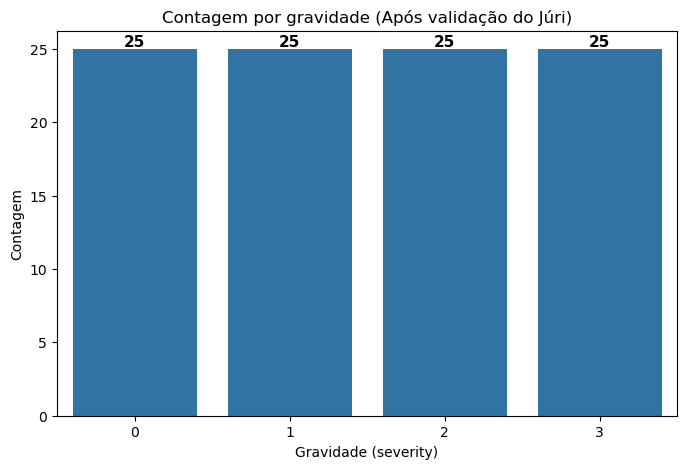

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adaptar o código para ordenar os dados de severity no eixo x de 0 a 3
order = [0, 1, 2, 3]
plt.figure(figsize=(8,5))
ax = sns.countplot(data=jury_df_estratificado, x="GPT_severity", order=order)
plt.title("Contagem por gravidade (Após validação do Júri)")
plt.xlabel("Gravidade (severity)")
plt.ylabel("Contagem")

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()

In [92]:
class Jury_Evaluation(dspy.Signature):
    """
    Você é um Especialista Sênior em Psicometria e Linguística Clínica.
    Sua tarefa é consolidar a classificação de severidade de depressão analisando múltiplos pareceres.

    CRITÉRIOS DE DECISÃO:
      1. Se houver UNANIMIDADE (4/4) ou CONSENSO FORTE (3/4 concordam com a Principal), confirme a Principal.
      2. Se houver DIVERGÊNCIA onde 2 concordam com a Principal, confirme a Principal.    
      3. Se houver DIVERGÊNCIA maior, leia o texto com extrema atenção aos CRITÉRIOS DE DESEMPATE e considere os VETORES de CONFIANÇA de cada modelo para cada classe ao decidir.
      4. Se não se sentir seguro para decidir, separe essa amostra para avaliação humana especializada.

    CRITÉRIOS DE DESEMPATE
      - Priorize menções explícitas de ideação suicida ou autolesão como "Severa".
      - Diferencie "Leve" de "Moderado" pelo impacto funcional descrito no texto.

    VETORES DE CONFIANÇA (Pesos de Autoridade por Classe [0, 1, 2, 3]):
      - GPT-4o-mini: [0.75, 0.70, 0.75, 0.85] -> Autoridade em Leve (1) e Moderada (2).
      - Claude Haiku: [0.80, 0.50, 0.70, 1.00] -> Autoridade em Ausente (0) e Severa (3). Bom em Leve (1) e Moderada (2).
      - Nemotron 12B: [1.00, 0.35, 0.70, 1.00] -> Autoridade em Ausente e Severa (3). Bom em Moderada (2)
      - Arcee Large: [0.70, 0.35, 0.60, 1.00] ->  Autoridade em Severa (3). Auxiliar forte em Moderada (2).
      - MiMo v2 Flash: [0.75, 0.35, 0.40, 1.00] -> Auxiliar forte em Ausente (0). Autoridade em Severa (3).
    """

    # Inputs: removendo Qwen, adicionando MIMO e DeepSeek
    texto_usuario = dspy.InputField(desc="Texto original extraído do Reddit")
    label_gpt4o = dspy.InputField(desc="Avaliação do modelo principal (GPT-4o-mini)")
    label_claude = dspy.InputField(desc="Avaliação do revisor A (Claude 3.5 Haiku)")
    label_nemotron = dspy.InputField(desc="Avaliação do revisor B (Nemotron 12B)")
    label_mimo = dspy.InputField(desc="Avaliação do revisor C (MIMO v2 Flash)")    
    label_arcee = dspy.InputField(desc="Avaliação do revisor D (Arcee Large)")   

    # Outputs
    rationale = dspy.OutputField(desc="Explique se houve consenso ou conflito e por que escolheu o rótulo final.")
    label_is_confirmed = dspy.OutputField(desc="Deve ser estritamente 'True' ou 'False'")
    final_label = dspy.OutputField(desc="Classificação final: 0, 1, 2, 3")

In [93]:
class Jury_Consensus(dspy.Module):
    def __init__(self):
        super().__init__()
        # ChainOfThought ativa o modo de raciocínio passo-a-passo
        self.juiz = dspy.ChainOfThought(Jury_Evaluation)

    def forward(self, texto_usuario, label_gpt4o, label_claude, label_nemotron, label_mimo, label_arcee):
        # O forward conecta os dados de entrada à Assinatura
        return self.juiz(
            texto_usuario=texto_usuario,
            label_gpt4o=label_gpt4o,
            label_claude=label_claude,
            label_nemotron=label_nemotron,
            label_mimo=label_mimo,
            label_arcee=label_arcee
        )

In [94]:
import concurrent.futures
from tqdm import tqdm

# Obter o LM do gpt4o-mini para usar no contexto
lm_gpt = juri_modelos.get("gpt4o_mini")
if lm_gpt is None:
    raise ValueError("LM do gpt4o-mini não encontrado! Verifique se 'juri_modelos' está definido.")

jury_llm = Jury_Consensus()

# Função auxiliar para processar cada linha
def process_row(row):
    """Processa uma linha do dataframe usando o Jury_Consensus com o modelo compilado do gpt4o-mini."""
    with dspy.context(lm=lm_gpt):
        output = jury_llm(
            texto_usuario=row['text'],
            label_gpt4o=row['GPT_severity'],
            label_claude=row['C_severity'],
            label_nemotron=row['N_severity'],
            label_mimo=row['M_severity'],
            label_arcee=row['A_severity']
        )
    # Retornar todos os 3 OutputFields da Signature: rationale, label_is_confirmed, final_label
    return {
        "text": row['text'],
        "rationale": getattr(output, 'rationale', None),
        "label_is_confirmed": getattr(output, 'label_is_confirmed', None),
        "final_label": getattr(output, 'final_label', None)
    }

# Processamento paralelo com barra de progresso
with concurrent.futures.ThreadPoolExecutor() as executor:
    # Submeter todas as tarefas
    future_to_row = {executor.submit(process_row, row): i for i, (_, row) in enumerate(jury_df_estratificado.iterrows())}
    results_buffer = [None] * len(future_to_row)
    
    # Processar resultados com barra de progresso usando tqdm
    for future in tqdm(concurrent.futures.as_completed(future_to_row), 
                       total=len(future_to_row), 
                       desc="Processando Jury_Consensus"):
        idx = future_to_row[future]
        try:
            result = future.result()
            results_buffer[idx] = result
        except Exception as exc:
            # Em caso de erro, criar resultado com valores None
            results_buffer[idx] = {
                "text": jury_df_estratificado.iloc[idx]['text'],
                "rationale": f'Erro: {exc}',
                "label_is_confirmed": None,
                "final_label": None
            }

# Transformar resultados em dataframe com todos os campos
jury_results_df = pd.DataFrame(results_buffer)


Processando Jury_Consensus: 100%|██████████| 100/100 [00:00<00:00, 105.39it/s]


In [95]:
jury_results_df

,text,rationale,label_is_confirmed,final_label
0,Só queria dizer isso.,"Houve unanimidade entre todos os revisores, to...",True,0
1,"Ola,me chamo Davi, não vou revelar minha idade...","Houve unanimidade entre todos os modelos, que ...",True,0
2,"Eu, homão machão, vim visitar minha mãe pro fi...","Houve uma divergência nas avaliações, com dois...",True,1
3,"É isso, nem me caiu a ficha ainda. Na sétima c...",Todos os modelos concordaram em classificar o ...,True,0
4,Anteriormente fiz um post antes de assistir a ...,"Houve uma leve divergência nas avaliações, com...",True,0
...,...,...,...,...
95,Desde cedo eu sempre fui rejeitado e maioria d...,"Houve uma divergência nas avaliações, com o GP...",True,3
96,"Oi, não quero muita enrolação e vou direto par...","Houve um consenso forte entre os avaliadores, ...",True,3
97,"Fobia-social, ansiedade, pobreza, solidão, e ""...","Houve unanimidade nas avaliações, com todos os...",True,3
98,"Querido Ina. Hoje foi um dia como os outros, f...","Houve um consenso forte, com 4 dos 5 avaliador...",True,3


In [96]:
jury_results_df.final_label.value_counts()

final_label
2    27
0    26
3    25
1    22
Name: count, dtype: int64

In [97]:
#jury_results_df.to_csv('jury_results_df_100_stratified.csv', index=False)

In [98]:
jury_results_df.label_is_confirmed.value_counts()

label_is_confirmed
True     92
False     8
Name: count, dtype: int64

In [99]:
# Calcular a proporção de label_is_confirmed=True para cada classe de final_label (0, 1, 2, 3)
# Normalizar: final_label pode vir como int ou str; label_is_confirmed pode vir como bool ou str "True"/"False"
df = jury_results_df.copy()
df['final_label_num'] = pd.to_numeric(df['final_label'], errors='coerce')
df['confirmed'] = df['label_is_confirmed'].apply(
    lambda x: x is True or (isinstance(x, str) and x.strip().lower() == 'true')
)

proporcoes = {}
for label in [0, 1, 2, 3]:
    mask = df['final_label_num'] == label
    total = mask.sum()
    confirmados = (df.loc[mask, 'confirmed']).sum()
    proporcao = confirmados / total if total > 0 else 0.0
    proporcoes[label] = proporcao
    print(f"Classe {label}: proporção confirmada = {proporcao:.2%} ({int(confirmados)}/{int(total)})")


Classe 0: proporção confirmada = 88.46% (23/26)
Classe 1: proporção confirmada = 86.36% (19/22)
Classe 2: proporção confirmada = 92.59% (25/27)
Classe 3: proporção confirmada = 100.00% (25/25)


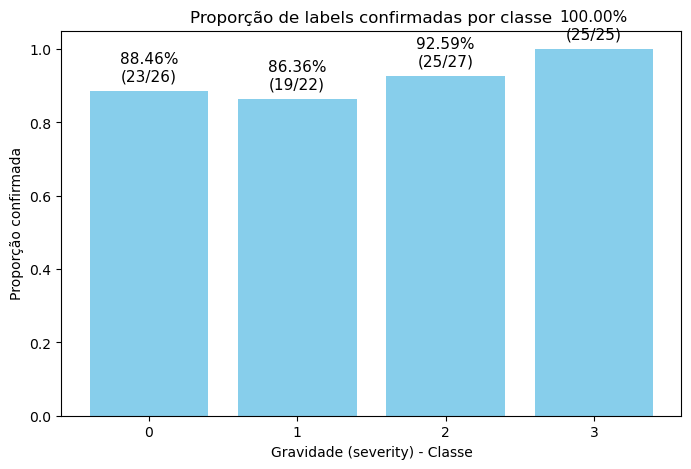

In [100]:
import matplotlib.pyplot as plt

# Criar listas para plotar
labels = list(proporcoes.keys())
proporcionais = [proporcoes[l] for l in labels]

# Extrair confirmados e totais para annotation
totais = []
confirmados = []
for label in labels:
    mask = df['final_label_num'] == label
    total = mask.sum()
    confirmado = (df.loc[mask, 'confirmed']).sum()
    totais.append(total)
    confirmados.append(confirmado)

plt.figure(figsize=(8,5))
bars = plt.bar(labels, proporcionais, color="skyblue")

plt.title("Proporção de labels confirmadas por classe")
plt.xlabel("Gravidade (severity) - Classe")
plt.ylabel("Proporção confirmada")

plt.ylim(0, 1.05)

# Adicionar anotações no topo das barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    annotation = f"{proporcionais[i]:.2%}\n({int(confirmados[i])}/{int(totais[i])})"
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             annotation, ha='center', va='bottom', fontsize=11)

plt.xticks(labels)
plt.show()

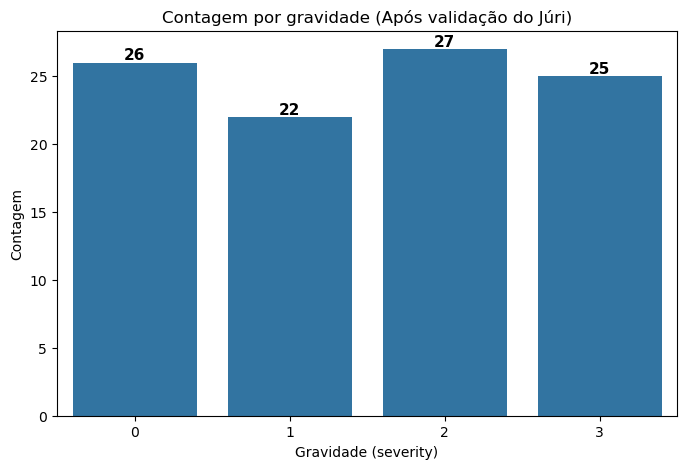

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adaptar o código para ordenar os dados de severity no eixo x de 0 a 3
order = [0, 1, 2, 3]
plt.figure(figsize=(8,5))
ax = sns.countplot(data=jury_results_df, x="final_label", order=order)
plt.title("Contagem por gravidade (Após validação do Júri)")
plt.xlabel("Gravidade (severity)")
plt.ylabel("Contagem")

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()

In [102]:
jury_df_estratificado

,text,GPT_severity,C_severity,N_severity,M_severity,A_severity
0,Só queria dizer isso.,0,0,0,0,0
1,"Ola,me chamo Davi, não vou revelar minha idade...",0,0,0,0,0
2,"Eu, homão machão, vim visitar minha mãe pro fi...",0,1,0,0,1
3,"É isso, nem me caiu a ficha ainda. Na sétima c...",0,0,0,0,0
4,Anteriormente fiz um post antes de assistir a ...,0,0,1,0,1
...,...,...,...,...,...,...
95,Desde cedo eu sempre fui rejeitado e maioria d...,3,2,2,1,2
96,"Oi, não quero muita enrolação e vou direto par...",3,3,3,3,2
97,"Fobia-social, ansiedade, pobreza, solidão, e ""...",3,3,3,3,3
98,"Querido Ina. Hoje foi um dia como os outros, f...",3,3,2,3,2


In [103]:
jury_results_df.head().to_dict()

{'text': {0: 'Só queria dizer isso.',
  1: 'Ola,me chamo Davi, não vou revelar minha idade por segurança,mas vamos la,na minha sala ha um menino autista,vamos chamalo de jonny,ele estava começando a ter um de seus surtos diários quando derrepente reparei que  dessa vez era pior,geralmente ele só grita e chora por causa do bullyng que sofre,eu como representante de classe apenas denúncio o que ocorre a direção da escola mas nunca fazem nada, então ele começou a jogar cadeiras para o alto,jogou sua d as carteiras em volta dele para os lados,isso fez meus materiáis se quebrarem o que me deixou muito bravo, além de que depois disso ele rasgou a alça da minha mochila por ser a coisa mais frágil perto dele na hora.Então eu bravo,me agaichei para pegar meus materiáis e vi minha mochila,que minha mãe se esforçou pra comprar e nem havia terminado de pagar quebrada,aquilo me deixou furioso,eu gritei "Só por que sofre de problemas e abusos não precisa descontar em quem esta em sua volta" ,nisso e

### Criação de um Juri com 500 amostras puramente aleatórias (5 modelos)

In [104]:
import pandas as pd

# Carrega os arquivos CSV
gpt_df = pd.read_csv("amostra_500_gpt4o.csv")
c_df = pd.read_csv("amostra_500_claude_haiku.csv")
n_df = pd.read_csv("amostra_500_nemotron_12b.csv")
m_df = pd.read_csv("amostra_500_mimo_v2_flash.csv")
a_df = pd.read_csv("amostra_500_arcee_trinty.csv")

# Adiciona os prefixos nas colunas severity de cada dataframe
gpt_df = gpt_df.rename(columns={'severity': 'GPT_severity'})
c_df = c_df.rename(columns={'severity': 'C_severity'})
n_df = n_df.rename(columns={'severity': 'N_severity'})

m_df = m_df.rename(columns={'severity': 'M_severity'})

a_df = a_df.rename(columns={'severity': 'A_severity'})

# Faz o merge pela coluna 'text'
jury_df_random_500 = gpt_df[['text', 'GPT_severity']].merge(
    c_df[['text', 'C_severity']], on='text'
).merge(
    n_df[['text', 'N_severity']], on='text'
).merge(
    m_df[['text', 'M_severity']], on='text'
).merge(
    a_df[['text', 'A_severity']], on='text'
)

jury_df_random_500

,text,GPT_severity,C_severity,N_severity,M_severity,A_severity
0,"Amiga, eu sinceramente acredito que ele queira...",0,0,0,0,0
1,eu falei pra minha esposa que ela que é a resp...,0,0,0,0,1
2,Cadê os mods,0,0,0,0,0
3,"Ganhou bem, mas pode ter certeza que esses nud...",0,0,0,0,0
4,Não sei mais o que faço. Sempre gostei muito d...,3,3,3,3,3
...,...,...,...,...,...,...
495,"Tenho meu cachorro desde 2015, o nome dele é H...",0,0,2,0,0
496,"""O nordeste é esquecido, e o norte nunca exist...",0,0,0,0,0
497,"Se instala na realidade, isso aí pode ter só a...",0,0,0,0,0
498,OBRIGADO EU PRECISAVA MUITO DISSO,0,0,0,0,0


In [105]:
jury_df_random_500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   text          500 non-null    object
 1   GPT_severity  500 non-null    int64 
 2   C_severity    500 non-null    object
 3   N_severity    497 non-null    object
 4   M_severity    500 non-null    int64 
 5   A_severity    500 non-null    object
dtypes: int64(2), object(4)
memory usage: 23.6+ KB


In [106]:
jury_df_random_500.N_severity.value_counts()

N_severity
0                                                      402
3                                                       39
2                                                       33
1                                                       16
error                                                    5
Moderada                                                 1
Low (preventive/management focus, not acute injury)      1
Name: count, dtype: int64

In [107]:
# Garanta que todos os valores em N_severity estejam entre 0 e 3 (categorias inteiras).
# Mapeia casos especiais de string para inteiros conforme especificado:
# "error" -> 0
# "Moderada" -> 2
# "Low (preventive/management focus, not acute injury)" -> 1

def clean_n_severity(val):
    if pd.isna(val):
        return 0  # ou pode ser np.nan se preferir
    if val == "error":
        return 0
    if val == "Moderada":
        return 2
    if val == "Low (preventive/management focus, not acute injury)":
        return 1
    try:
        int_val = int(val)
        if int_val in [0, 1, 2, 3]:
            return int_val
        else:
            # Valores fora do intervalo vão para 0 por padrão
            return 0
    except:
        return 0

jury_df_random_500["N_severity"] = jury_df_random_500["N_severity"].apply(clean_n_severity).astype("int64")




In [108]:
jury_df_random_500.N_severity.value_counts()

N_severity
0    410
3     39
2     34
1     17
Name: count, dtype: int64

In [109]:
# Converta as colunas indicadas para int64, tratando valores não convertíveis como 0
cols_to_int64 = ["C_severity", "A_severity"]

for col in cols_to_int64:
    jury_df_random_500[col] = pd.to_numeric(jury_df_random_500[col], errors="coerce").fillna(0).astype("int64")




In [110]:
jury_df_random_500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   text          500 non-null    object
 1   GPT_severity  500 non-null    int64 
 2   C_severity    500 non-null    int64 
 3   N_severity    500 non-null    int64 
 4   M_severity    500 non-null    int64 
 5   A_severity    500 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 23.6+ KB


In [111]:
jury_df_random_500.to_csv('jury_df_500_random.csv', index=False)

In [112]:
# Renomeando as colunas do DataFrame jury_df conforme padrão desejado
jury_df_random_500 = jury_df_random_500.rename(
    columns={
        'GPT_severity': 'severity_gpt4o_mini',
        'C_severity': 'severity_claude_haiku',
        'N_severity': 'severity_nemotron_12b',
        'M_severity': 'severity_mimo_v2_flash',
        'A_severity': 'severity_arcee_trinity'
    }
)

In [113]:
jury_df_random_500

,text,severity_gpt4o_mini,severity_claude_haiku,severity_nemotron_12b,severity_mimo_v2_flash,severity_arcee_trinity
0,"Amiga, eu sinceramente acredito que ele queira...",0,0,0,0,0
1,eu falei pra minha esposa que ela que é a resp...,0,0,0,0,1
2,Cadê os mods,0,0,0,0,0
3,"Ganhou bem, mas pode ter certeza que esses nud...",0,0,0,0,0
4,Não sei mais o que faço. Sempre gostei muito d...,3,3,3,3,3
...,...,...,...,...,...,...
495,"Tenho meu cachorro desde 2015, o nome dele é H...",0,0,2,0,0
496,"""O nordeste é esquecido, e o norte nunca exist...",0,0,0,0,0
497,"Se instala na realidade, isso aí pode ter só a...",0,0,0,0,0
498,OBRIGADO EU PRECISAVA MUITO DISSO,0,0,0,0,0


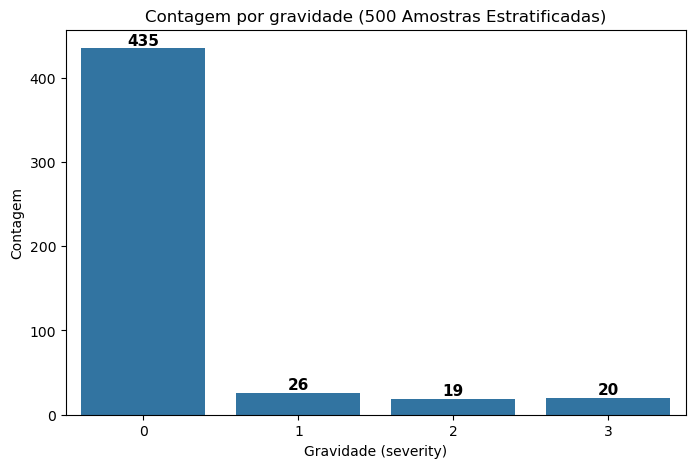

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adaptar o código para ordenar os dados de severity no eixo x de 0 a 3
order = [0, 1, 2, 3]
plt.figure(figsize=(8,5))
ax = sns.countplot(data=jury_df_random_500, x="severity_gpt4o_mini", order=order)
plt.title("Contagem por gravidade (500 Amostras Estratificadas)")
plt.xlabel("Gravidade (severity)")
plt.ylabel("Contagem")

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()

In [115]:
#Configuração do DeepSeek R1 como organizador do júri

import dspy

dspy.configure(lm=juri_modelos["deepseek_r1"])

In [116]:
class Jury_Evaluation(dspy.Signature):
    """
    Você é um Especialista Sênior em Psicometria e Linguística Clínica.
    Sua tarefa é consolidar a classificação de severidade de depressão analisando múltiplos pareceres.

    CRITÉRIOS DE DECISÃO:
      1. Se houver UNANIMIDADE (4/4) ou CONSENSO FORTE (3/4 concordam com a Principal), confirme a Principal.
      2. Se houver DIVERGÊNCIA onde 2 concordam com a Principal, confirme a Principal.    
      3. Se houver DIVERGÊNCIA maior, leia o texto com extrema atenção aos CRITÉRIOS DE DESEMPATE e considere os VETORES de CONFIANÇA de cada modelo para cada classe ao decidir.
      4. Se não se sentir seguro para decidir, separe essa amostra para avaliação humana especializada.

    CRITÉRIOS DE DESEMPATE
      - Priorize menções explícitas de ideação suicida ou autolesão como "Severa".
      - Diferencie "Leve" de "Moderado" pelo impacto funcional descrito no texto.

    VETORES DE CONFIANÇA (Pesos de Autoridade por Classe [0, 1, 2, 3]):
      - GPT-4o-mini: [0.75, 0.70, 0.75, 0.85] -> Autoridade em Leve (1) e Moderada (2).
      - Claude Haiku: [0.80, 0.50, 0.70, 1.00] -> Autoridade em Ausente (0) e Severa (3). Bom em Leve (1) e Moderada (2).
      - Nemotron 12B: [1.00, 0.35, 0.70, 1.00] -> Autoridade em Ausente e Severa (3). Bom em Moderada (2)
      - Arcee Large: [0.70, 0.35, 0.60, 1.00] ->  Autoridade em Severa (3). Auxiliar forte em Moderada (2).
      - MiMo v2 Flash: [0.75, 0.35, 0.40, 1.00] -> Auxiliar forte em Ausente (0). Autoridade em Severa (3).
    """

    # Inputs: removendo Qwen, adicionando MIMO e DeepSeek
    texto_usuario = dspy.InputField(desc="Texto original extraído do Reddit")
    label_gpt4o = dspy.InputField(desc="Avaliação do modelo principal (GPT-4o-mini)")
    label_claude = dspy.InputField(desc="Avaliação do revisor A (Claude 3.5 Haiku)")
    label_nemotron = dspy.InputField(desc="Avaliação do revisor B (Nemotron 12B)")
    label_mimo = dspy.InputField(desc="Avaliação do revisor C (MIMO v2 Flash)")    
    label_arcee = dspy.InputField(desc="Avaliação do revisor D (Arcee Large)")   

    # Outputs
    rationale = dspy.OutputField(desc="Explique se houve consenso ou conflito e por que escolheu o rótulo final.")
    label_is_confirmed = dspy.OutputField(desc="Deve ser estritamente 'True' ou 'False'")
    final_label = dspy.OutputField(desc="Classificação final: 0, 1, 2, 3")

In [117]:
class Jury_Consensus(dspy.Module):
    def __init__(self):
        super().__init__()
        # ChainOfThought ativa o modo de raciocínio passo-a-passo
        self.juiz = dspy.ChainOfThought(Jury_Evaluation)

    def forward(self, texto_usuario, label_gpt4o, label_claude, label_nemotron, label_mimo, label_arcee):
        # O forward conecta os dados de entrada à Assinatura
        return self.juiz(
            texto_usuario=texto_usuario,
            label_gpt4o=label_gpt4o,
            label_claude=label_claude,
            label_nemotron=label_nemotron,
            label_mimo=label_mimo,
            label_arcee=label_arcee
        )

In [118]:
jury_df_random_500.head()

,text,severity_gpt4o_mini,severity_claude_haiku,severity_nemotron_12b,severity_mimo_v2_flash,severity_arcee_trinity
0,"Amiga, eu sinceramente acredito que ele queira...",0,0,0,0,0
1,eu falei pra minha esposa que ela que é a resp...,0,0,0,0,1
2,Cadê os mods,0,0,0,0,0
3,"Ganhou bem, mas pode ter certeza que esses nud...",0,0,0,0,0
4,Não sei mais o que faço. Sempre gostei muito d...,3,3,3,3,3


In [119]:
import concurrent.futures
from tqdm import tqdm

# Obter o LM do gpt4o-mini para usar no contexto
lm_gpt = juri_modelos.get("gpt4o_mini")
if lm_gpt is None:
    raise ValueError("LM do gpt4o-mini não encontrado! Verifique se 'juri_modelos' está definido.")

jury_llm = Jury_Consensus()

# Função auxiliar para processar cada linha
def process_row(row):
    """Processa uma linha do dataframe usando o Jury_Consensus com o modelo compilado do gpt4o-mini."""
    with dspy.context(lm=lm_gpt):
        output = jury_llm(
            texto_usuario=row['text'],
            label_gpt4o=row['severity_gpt4o_mini'],
            label_claude=row['severity_claude_haiku'],
            label_nemotron=row['severity_nemotron_12b'],
            label_mimo=row['severity_mimo_v2_flash'],
            label_arcee=row['severity_arcee_trinity']
        )
    # Retornar todos os 3 OutputFields da Signature: rationale, label_is_confirmed, final_label
    return {
        "text": row['text'],
        "rationale": getattr(output, 'rationale', None),
        "label_is_confirmed": getattr(output, 'label_is_confirmed', None),
        "final_label": getattr(output, 'final_label', None)
    }

# Processamento paralelo com barra de progresso
with concurrent.futures.ThreadPoolExecutor() as executor:
    # Submeter todas as tarefas
    future_to_row = {executor.submit(process_row, row): i for i, (_, row) in enumerate(jury_df_random_500.iterrows())}
    results_buffer = [None] * len(future_to_row)
    
    # Processar resultados com barra de progresso usando tqdm
    for future in tqdm(concurrent.futures.as_completed(future_to_row), 
                       total=len(future_to_row), 
                       desc="Processando Jury_Consensus"):
        idx = future_to_row[future]
        try:
            result = future.result()
            results_buffer[idx] = result
        except Exception as exc:
            # Em caso de erro, criar resultado com valores None
            results_buffer[idx] = {
                "text": jury_df_random_500.iloc[idx]['text'],
                "rationale": f'Erro: {exc}',
                "label_is_confirmed": None,
                "final_label": None
            }

# Transformar resultados em dataframe com todos os campos
jury_results_df = pd.DataFrame(results_buffer)


Processando Jury_Consensus: 100%|██████████| 500/500 [00:05<00:00, 84.33it/s] 


In [120]:
jury_results_df


,text,rationale,label_is_confirmed,final_label
0,"Amiga, eu sinceramente acredito que ele queira...","Houve unanimidade entre todos os revisores, to...",True,0
1,eu falei pra minha esposa que ela que é a resp...,"Houve uma divergência, pois 4 dos 5 modelos co...",True,0
2,Cadê os mods,"Houve unanimidade entre todos os revisores, co...",True,0
3,"Ganhou bem, mas pode ter certeza que esses nud...","Houve unanimidade entre todos os revisores, to...",True,0
4,Não sei mais o que faço. Sempre gostei muito d...,"Houve unanimidade entre todos os avaliadores, ...",True,3
...,...,...,...,...
495,"Tenho meu cachorro desde 2015, o nome dele é H...","Houve um consenso forte entre os avaliadores, ...",True,0
496,"""O nordeste é esquecido, e o norte nunca exist...","Houve unanimidade entre todos os avaliadores, ...",True,0
497,"Se instala na realidade, isso aí pode ter só a...","Houve unanimidade entre todos os revisores, to...",True,0
498,OBRIGADO EU PRECISAVA MUITO DISSO,"Houve unanimidade entre todos os revisores, to...",True,0


In [121]:
jury_results_df.to_csv('jury_results_df_500_random.csv', index=False)

In [122]:
jury_results_df.label_is_confirmed.value_counts()


label_is_confirmed
True     484
False     16
Name: count, dtype: int64

In [123]:
jury_results_df.label_is_confirmed.value_counts(normalize=True).mul(100).round(2)

label_is_confirmed
True     96.8
False     3.2
Name: proportion, dtype: float64

In [124]:
jury_results_df.final_label.value_counts()



final_label
0    441
2     23
1     19
3     17
Name: count, dtype: int64

In [125]:
jury_results_df.final_label.value_counts(normalize=True).mul(100).round(2)

final_label
0    88.2
2     4.6
1     3.8
3     3.4
Name: proportion, dtype: float64

In [126]:
# Calcular a proporção de label_is_confirmed=True para cada classe de final_label (0, 1, 2, 3)
# Normalizar: final_label pode vir como int ou str; label_is_confirmed pode vir como bool ou str "True"/"False"
df = jury_results_df.copy()
df['final_label_num'] = pd.to_numeric(df['final_label'], errors='coerce')
df['confirmed'] = df['label_is_confirmed'].apply(
    lambda x: x is True or (isinstance(x, str) and x.strip().lower() == 'true')
)

proporcoes = {}
for label in [0, 1, 2, 3]:
    mask = df['final_label_num'] == label
    total = mask.sum()
    confirmados = (df.loc[mask, 'confirmed']).sum()
    proporcao = confirmados / total if total > 0 else 0.0
    proporcoes[label] = proporcao
    print(f"Classe {label}: proporção confirmada = {proporcao:.2%} ({int(confirmados)}/{int(total)})")


Classe 0: proporção confirmada = 99.09% (437/441)
Classe 1: proporção confirmada = 78.95% (15/19)
Classe 2: proporção confirmada = 65.22% (15/23)
Classe 3: proporção confirmada = 100.00% (17/17)


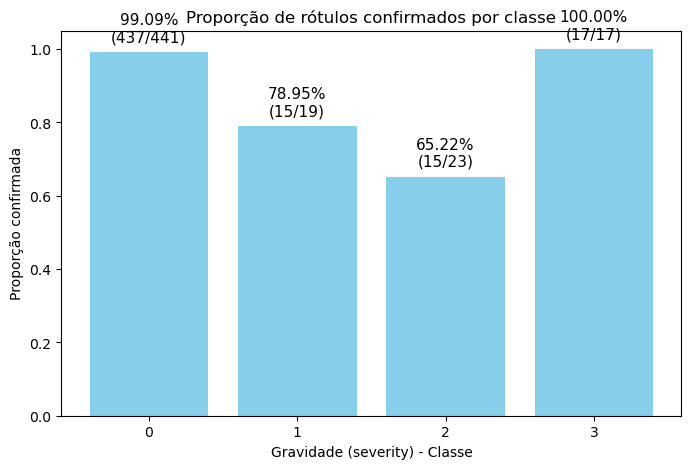

In [127]:
import matplotlib.pyplot as plt

# Criar listas para plotar
labels = list(proporcoes.keys())
proporcionais = [proporcoes[l] for l in labels]

# Extrair confirmados e totais para annotation
totais = []
confirmados = []
for label in labels:
    mask = df['final_label_num'] == label
    total = mask.sum()
    confirmado = (df.loc[mask, 'confirmed']).sum()
    totais.append(total)
    confirmados.append(confirmado)

plt.figure(figsize=(8,5))
bars = plt.bar(labels, proporcionais, color="skyblue")

plt.title("Proporção de rótulos confirmados por classe")
plt.xlabel("Gravidade (severity) - Classe")
plt.ylabel("Proporção confirmada")

plt.ylim(0, 1.05)

# Adicionar anotações no topo das barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    annotation = f"{proporcionais[i]:.2%}\n({int(confirmados[i])}/{int(totais[i])})"
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             annotation, ha='center', va='bottom', fontsize=11)

plt.xticks(labels)
plt.show()

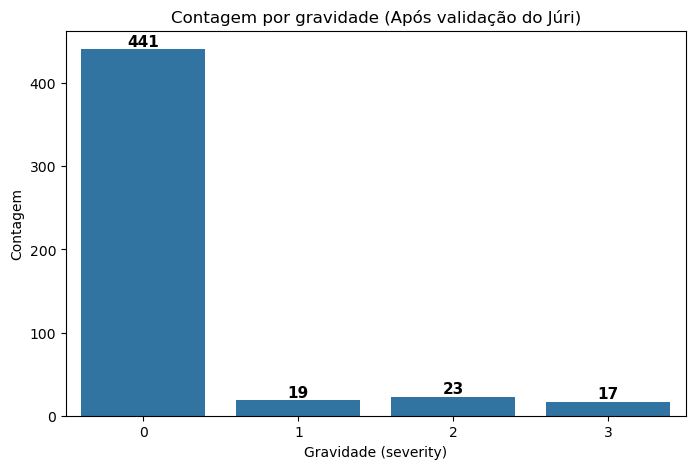

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adaptar o código para ordenar os dados de severity no eixo x de 0 a 3
order = [0, 1, 2, 3]
plt.figure(figsize=(8,5))
ax = sns.countplot(data=jury_results_df, x="final_label", order=order)
plt.title("Contagem por gravidade (Após validação do Júri)")
plt.xlabel("Gravidade (severity)")
plt.ylabel("Contagem")

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()

## Avaliação do juri Concatenando todas as amostras

In [129]:
import pandas as pd

# Lista dos nomes dos arquivos CSV
csv_files = [
    'jury_df_100_samples_7_models.csv',
    'juri_estratificado_100_5_modelos.csv',
    'jury_df_500_random.csv'
]

# Ler cada arquivo em um DataFrame e concatenar
dfs = [pd.read_csv(f) for f in csv_files]
jury_concat_df = pd.concat(dfs, ignore_index=True)

# Exibir as primeiras linhas para verificação
jury_concat_df

,text,GPT_severity,C_severity,N_severity,Q_severity,M_severity,D_severity,A_severity
0,Boa tarde pessoal.Estou fazendo este post aqui...,2,2,2,1.0,2,2.0,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,1,2,1,1.0,1,2.0,2
2,Vocês demonstram afeto em publico quando estão...,0,0,0,1.0,0,0.0,0
3,Acabei de ver que um mercado que vou toda sema...,0,0,0,0.0,0,0.0,0
4,O título é auto-explicativo. E é isso kkkkkk t...,1,1,1,1.0,0,0.0,0
...,...,...,...,...,...,...,...,...
695,"Tenho meu cachorro desde 2015, o nome dele é H...",0,0,2,NaN,0,NaN,0
696,"""O nordeste é esquecido, e o norte nunca exist...",0,0,0,NaN,0,NaN,0
697,"Se instala na realidade, isso aí pode ter só a...",0,0,0,NaN,0,NaN,0
698,OBRIGADO EU PRECISAVA MUITO DISSO,0,0,0,NaN,0,NaN,0


In [130]:
jury_concat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          700 non-null    object 
 1   GPT_severity  700 non-null    int64  
 2   C_severity    700 non-null    int64  
 3   N_severity    700 non-null    int64  
 4   Q_severity    100 non-null    float64
 5   M_severity    700 non-null    int64  
 6   D_severity    100 non-null    float64
 7   A_severity    700 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 43.9+ KB


In [131]:
jury_concat_df.A_severity.value_counts()

A_severity
0    514
1     82
2     52
3     52
Name: count, dtype: int64

In [132]:
# Remover as colunas D_severity e Q_severity, se existirem
cols_to_remove = ['D_severity', 'Q_severity']
jury_concat_df = jury_concat_df.drop(columns=[c for c in cols_to_remove if c in jury_concat_df.columns])
jury_concat_df

,text,GPT_severity,C_severity,N_severity,M_severity,A_severity
0,Boa tarde pessoal.Estou fazendo este post aqui...,2,2,2,2,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,1,2,1,1,2
2,Vocês demonstram afeto em publico quando estão...,0,0,0,0,0
3,Acabei de ver que um mercado que vou toda sema...,0,0,0,0,0
4,O título é auto-explicativo. E é isso kkkkkk t...,1,1,1,0,0
...,...,...,...,...,...,...
695,"Tenho meu cachorro desde 2015, o nome dele é H...",0,0,2,0,0
696,"""O nordeste é esquecido, e o norte nunca exist...",0,0,0,0,0
697,"Se instala na realidade, isso aí pode ter só a...",0,0,0,0,0
698,OBRIGADO EU PRECISAVA MUITO DISSO,0,0,0,0,0


In [135]:
import pandas as pd

# Lista dos nomes dos arquivos CSV
csv_files = [
    'jury_results_df_100_samples.csv',
    'jury_results_df_100_stratified.csv',
    'jury_results_df_500_random.csv'
]

# Ler cada arquivo em um DataFrame e concatenar
dfs = [pd.read_csv(f) for f in csv_files]
jury_results_concat_df = pd.concat(dfs, ignore_index=True)

# Exibir as primeiras linhas para verificação
jury_results_concat_df

,text,rationale,label_is_confirmed,final_label
0,Boa tarde pessoal.Estou fazendo este post aqui...,"Houve unanimidade nas avaliações, com todos os...",True,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,"Houve uma divergência nas classificações, com ...",False,2
2,Vocês demonstram afeto em publico quando estão...,"Houve unanimidade entre os cinco modelos, todo...",True,0
3,Acabei de ver que um mercado que vou toda sema...,"Houve unanimidade entre todos os revisores, to...",True,0
4,O título é auto-explicativo. E é isso kkkkkk t...,Houve um consenso forte entre três dos quatro ...,True,1
...,...,...,...,...
695,"Tenho meu cachorro desde 2015, o nome dele é H...","Houve um consenso forte entre os avaliadores, ...",True,0
696,"""O nordeste é esquecido, e o norte nunca exist...","Houve unanimidade entre todos os avaliadores, ...",True,0
697,"Se instala na realidade, isso aí pode ter só a...","Houve unanimidade entre todos os revisores, to...",True,0
698,OBRIGADO EU PRECISAVA MUITO DISSO,"Houve unanimidade entre todos os revisores, to...",True,0


In [136]:
jury_results_concat_df = jury_results_concat_df.drop_duplicates(ignore_index=True)
jury_results_concat_df

,text,rationale,label_is_confirmed,final_label
0,Boa tarde pessoal.Estou fazendo este post aqui...,"Houve unanimidade nas avaliações, com todos os...",True,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,"Houve uma divergência nas classificações, com ...",False,2
2,Vocês demonstram afeto em publico quando estão...,"Houve unanimidade entre os cinco modelos, todo...",True,0
3,Acabei de ver que um mercado que vou toda sema...,"Houve unanimidade entre todos os revisores, to...",True,0
4,O título é auto-explicativo. E é isso kkkkkk t...,Houve um consenso forte entre três dos quatro ...,True,1
...,...,...,...,...
694,"Tenho meu cachorro desde 2015, o nome dele é H...","Houve um consenso forte entre os avaliadores, ...",True,0
695,"""O nordeste é esquecido, e o norte nunca exist...","Houve unanimidade entre todos os avaliadores, ...",True,0
696,"Se instala na realidade, isso aí pode ter só a...","Houve unanimidade entre todos os revisores, to...",True,0
697,OBRIGADO EU PRECISAVA MUITO DISSO,"Houve unanimidade entre todos os revisores, to...",True,0


In [137]:
if 'Unnamed: 0' in jury_results_concat_df.columns:
    jury_results_concat_df = jury_results_concat_df.drop(columns=['Unnamed: 0'])

In [138]:
jury_results_concat_df

,text,rationale,label_is_confirmed,final_label
0,Boa tarde pessoal.Estou fazendo este post aqui...,"Houve unanimidade nas avaliações, com todos os...",True,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,"Houve uma divergência nas classificações, com ...",False,2
2,Vocês demonstram afeto em publico quando estão...,"Houve unanimidade entre os cinco modelos, todo...",True,0
3,Acabei de ver que um mercado que vou toda sema...,"Houve unanimidade entre todos os revisores, to...",True,0
4,O título é auto-explicativo. E é isso kkkkkk t...,Houve um consenso forte entre três dos quatro ...,True,1
...,...,...,...,...
694,"Tenho meu cachorro desde 2015, o nome dele é H...","Houve um consenso forte entre os avaliadores, ...",True,0
695,"""O nordeste é esquecido, e o norte nunca exist...","Houve unanimidade entre todos os avaliadores, ...",True,0
696,"Se instala na realidade, isso aí pode ter só a...","Houve unanimidade entre todos os revisores, to...",True,0
697,OBRIGADO EU PRECISAVA MUITO DISSO,"Houve unanimidade entre todos os revisores, to...",True,0


In [139]:
jury_results_concat_df.label_is_confirmed.value_counts()


label_is_confirmed
True     664
False     35
Name: count, dtype: int64

In [140]:
jury_results_concat_df.final_label.value_counts(normalize=True).mul(100).round(2)

final_label
0    73.68
3     9.16
2     8.87
1     8.30
Name: proportion, dtype: float64

In [141]:
# Calcular a proporção de label_is_confirmed=True para cada classe de final_label (0, 1, 2, 3)
# Normalizar: final_label pode vir como int ou str; label_is_confirmed pode vir como bool ou str "True"/"False"
df = jury_results_concat_df.copy()
df['final_label_num'] = pd.to_numeric(df['final_label'], errors='coerce')
df['confirmed'] = df['label_is_confirmed'].apply(
    lambda x: x is True or (isinstance(x, str) and x.strip().lower() == 'true')
)

proporcoes = {}
for label in [0, 1, 2, 3]:
    mask = df['final_label_num'] == label
    total = mask.sum()
    confirmados = (df.loc[mask, 'confirmed']).sum()
    proporcao = confirmados / total if total > 0 else 0.0
    proporcoes[label] = proporcao
    print(f"Classe {label}: proporção confirmada = {proporcao:.2%} ({int(confirmados)}/{int(total)})")


Classe 0: proporção confirmada = 97.67% (503/515)
Classe 1: proporção confirmada = 82.76% (48/58)
Classe 2: proporção confirmada = 79.03% (49/62)
Classe 3: proporção confirmada = 100.00% (64/64)


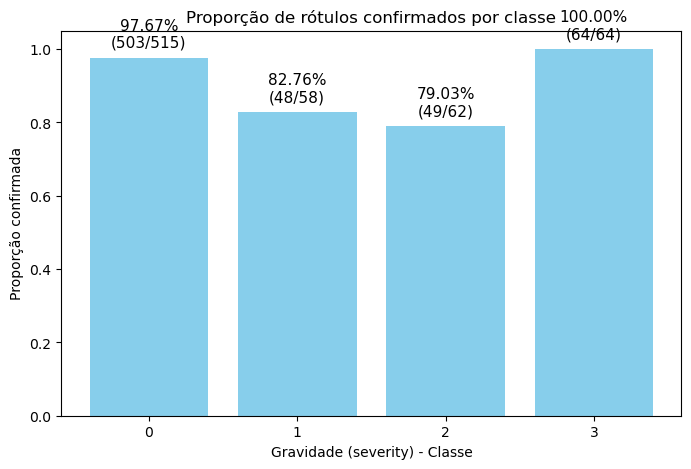

In [142]:
import matplotlib.pyplot as plt

# Criar listas para plotar
labels = list(proporcoes.keys())
proporcionais = [proporcoes[l] for l in labels]

# Extrair confirmados e totais para annotation
totais = []
confirmados = []
for label in labels:
    mask = df['final_label_num'] == label
    total = mask.sum()
    confirmado = (df.loc[mask, 'confirmed']).sum()
    totais.append(total)
    confirmados.append(confirmado)

plt.figure(figsize=(8,5))
bars = plt.bar(labels, proporcionais, color="skyblue")

plt.title("Proporção de rótulos confirmados por classe")
plt.xlabel("Gravidade (severity) - Classe")
plt.ylabel("Proporção confirmada")

plt.ylim(0, 1.05)

# Adicionar anotações no topo das barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    annotation = f"{proporcionais[i]:.2%}\n({int(confirmados[i])}/{int(totais[i])})"
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             annotation, ha='center', va='bottom', fontsize=11)

plt.xticks(labels)
plt.show()

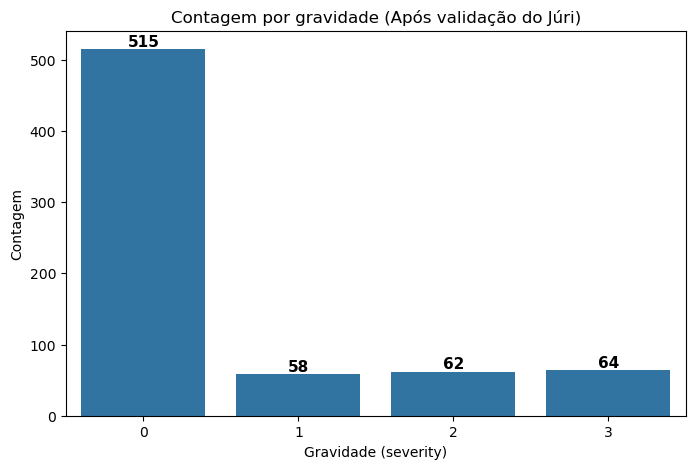

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adaptar o código para ordenar os dados de severity no eixo x de 0 a 3
order = [0, 1, 2, 3]
plt.figure(figsize=(8,5))
ax = sns.countplot(data=jury_results_concat_df, x="final_label", order=order)
plt.title("Contagem por gravidade (Após validação do Júri)")
plt.xlabel("Gravidade (severity)")
plt.ylabel("Contagem")

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()

Criação do Dataset para revisão Humana

In [144]:
import pandas as pd

# Lista dos nomes dos arquivos CSV
csv_files = [
    'jury_df_100_samples_7_models.csv',
    'juri_estratificado_100_5_modelos.csv',
    'jury_df_500_random.csv'
]

# Ler cada arquivo em um DataFrame e concatenar
dfs = [pd.read_csv(f) for f in csv_files]
jury_concat_df = pd.concat(dfs, ignore_index=True)

# Exibir as primeiras linhas para verificação
jury_concat_df

,text,GPT_severity,C_severity,N_severity,Q_severity,M_severity,D_severity,A_severity
0,Boa tarde pessoal.Estou fazendo este post aqui...,2,2,2,1.0,2,2.0,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,1,2,1,1.0,1,2.0,2
2,Vocês demonstram afeto em publico quando estão...,0,0,0,1.0,0,0.0,0
3,Acabei de ver que um mercado que vou toda sema...,0,0,0,0.0,0,0.0,0
4,O título é auto-explicativo. E é isso kkkkkk t...,1,1,1,1.0,0,0.0,0
...,...,...,...,...,...,...,...,...
695,"Tenho meu cachorro desde 2015, o nome dele é H...",0,0,2,NaN,0,NaN,0
696,"""O nordeste é esquecido, e o norte nunca exist...",0,0,0,NaN,0,NaN,0
697,"Se instala na realidade, isso aí pode ter só a...",0,0,0,NaN,0,NaN,0
698,OBRIGADO EU PRECISAVA MUITO DISSO,0,0,0,NaN,0,NaN,0


In [145]:
jury_concat_df.A_severity.value_counts()

A_severity
0    514
1     82
2     52
3     52
Name: count, dtype: int64

In [146]:
# Remover as colunas D_severity e Q_severity, se existirem
cols_to_remove = ['D_severity', 'Q_severity']
jury_concat_df = jury_concat_df.drop(columns=[c for c in cols_to_remove if c in jury_concat_df.columns])
jury_concat_df

,text,GPT_severity,C_severity,N_severity,M_severity,A_severity
0,Boa tarde pessoal.Estou fazendo este post aqui...,2,2,2,2,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,1,2,1,1,2
2,Vocês demonstram afeto em publico quando estão...,0,0,0,0,0
3,Acabei de ver que um mercado que vou toda sema...,0,0,0,0,0
4,O título é auto-explicativo. E é isso kkkkkk t...,1,1,1,0,0
...,...,...,...,...,...,...
695,"Tenho meu cachorro desde 2015, o nome dele é H...",0,0,2,0,0
696,"""O nordeste é esquecido, e o norte nunca exist...",0,0,0,0,0
697,"Se instala na realidade, isso aí pode ter só a...",0,0,0,0,0
698,OBRIGADO EU PRECISAVA MUITO DISSO,0,0,0,0,0


In [147]:
jury_concat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   text          700 non-null    object
 1   GPT_severity  700 non-null    int64 
 2   C_severity    700 non-null    int64 
 3   N_severity    700 non-null    int64 
 4   M_severity    700 non-null    int64 
 5   A_severity    700 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 32.9+ KB


In [148]:
import pandas as pd

# Lista dos nomes dos arquivos CSV
csv_files = [
    'jury_results_df_100_samples.csv',
    'jury_results_df_100_stratified.csv',
    'jury_results_df_500_random.csv'
]

# Ler cada arquivo em um DataFrame e concatenar
dfs = [pd.read_csv(f) for f in csv_files]
jury_results_concat_df = pd.concat(dfs, ignore_index=True)

# Exibir as primeiras linhas para verificação
jury_results_concat_df

,text,rationale,label_is_confirmed,final_label
0,Boa tarde pessoal.Estou fazendo este post aqui...,"Houve unanimidade nas avaliações, com todos os...",True,2
1,Moro com a minha mãe e ela é tudo que eu tenho...,"Houve uma divergência nas classificações, com ...",False,2
2,Vocês demonstram afeto em publico quando estão...,"Houve unanimidade entre os cinco modelos, todo...",True,0
3,Acabei de ver que um mercado que vou toda sema...,"Houve unanimidade entre todos os revisores, to...",True,0
4,O título é auto-explicativo. E é isso kkkkkk t...,Houve um consenso forte entre três dos quatro ...,True,1
...,...,...,...,...
695,"Tenho meu cachorro desde 2015, o nome dele é H...","Houve um consenso forte entre os avaliadores, ...",True,0
696,"""O nordeste é esquecido, e o norte nunca exist...","Houve unanimidade entre todos os avaliadores, ...",True,0
697,"Se instala na realidade, isso aí pode ter só a...","Houve unanimidade entre todos os revisores, to...",True,0
698,OBRIGADO EU PRECISAVA MUITO DISSO,"Houve unanimidade entre todos os revisores, to...",True,0


In [149]:
#jury_results_concat_df = jury_results_concat_df.drop_duplicates(ignore_index=True)
#jury_results_concat_df

In [150]:
#if 'Unnamed: 0' in jury_results_concat_df.columns:
#    jury_results_concat_df = jury_results_concat_df.drop(columns=['Unnamed: 0'])

In [151]:
jury_results_concat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   text                700 non-null    object
 1   rationale           700 non-null    object
 2   label_is_confirmed  700 non-null    bool  
 3   final_label         700 non-null    int64 
dtypes: bool(1), int64(1), object(2)
memory usage: 17.2+ KB


In [152]:
jury_results_concat_df.label_is_confirmed.value_counts()

label_is_confirmed
True     665
False     35
Name: count, dtype: int64

In [153]:
# Realiza merge entre os três dataframes (jury_concat_df, jury_results_concat_df e depre_parallel_df) com base na coluna 'text'.
# Os sufixos serão aplicados para colunas duplicadas relativas a "rationale".


depre_parallel_df = pd.read_csv("DepreRedditBR_parallel_50k.csv")

merged_df = pd.merge(depre_parallel_df, jury_concat_df, on='text', how='inner')
merged_df = pd.merge(merged_df, jury_results_concat_df, on='text', how='inner', suffixes=("_GPT", "_Jury"))

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   text                706 non-null    object
 1   severity            706 non-null    int64 
 2   rationale_GPT       706 non-null    object
 3   probs               706 non-null    object
 4   GPT_severity        706 non-null    int64 
 5   C_severity          706 non-null    int64 
 6   N_severity          706 non-null    int64 
 7   M_severity          706 non-null    int64 
 8   A_severity          706 non-null    int64 
 9   rationale_Jury      706 non-null    object
 10  label_is_confirmed  706 non-null    bool  
 11  final_label         706 non-null    int64 
dtypes: bool(1), int64(7), object(4)
memory usage: 61.5+ KB


In [154]:
# Removendo amostras duplicadas com base na coluna 'text'
merged_df = merged_df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
merged_df = merged_df.drop(columns=['GPT_severity'])
merged_df



,text,severity,rationale_GPT,probs,C_severity,N_severity,M_severity,A_severity,rationale_Jury,label_is_confirmed,final_label
0,Esses tempos vejo que muitas pessoas estão rec...,0,O autor demonstra uma preocupação com a percep...,"[0.9, 0.05, 0.03, 0.02]",0,0,0,0,"Houve unanimidade entre todos os avaliadores, ...",True,0
1,Cadê os mods,0,A ausência de qualquer conteúdo emocional ou s...,"[1.0, 0.0, 0.0, 0.0]",0,0,0,0,"Houve unanimidade entre todos os revisores, co...",True,0
2,Jah fortaleceu com a lari,0,A falta de conteúdo emocional ou descritivo no...,"[1.0, 0.0, 0.0, 0.0]",0,0,0,0,"Houve unanimidade entre todos os revisores, co...",True,0
3,estou cansado dessa infâme esquerda x direita....,0,O autor apresenta uma reflexão sobre política ...,"[0.9, 0.05, 0.05, 0.0]",0,0,0,0,"Houve unanimidade entre os cinco modelos, todo...",True,0
4,"Tenho meu cachorro desde 2015, o nome dele é H...",0,O autor demonstra tristeza e preocupação com a...,"[0.7, 0.2, 0.1, 0.0]",0,2,0,0,"Houve um consenso forte entre os avaliadores, ...",True,0
...,...,...,...,...,...,...,...,...,...,...,...
692,"eu e ela terminamos a aproximadamente 2 meses,...",2,"Os sentimentos de culpa, tristeza e a reabertu...","[0.0, 0.4, 0.4, 0.2]",1,1,2,1,"Houve uma divergência nas classificações, com ...",True,1
693,"Eu acredito que sim, e temo muito por dia.Mas ...",0,"Embora o autor expresse preocupações e medos, ...","[0.7, 0.2, 0.1, 0.0]",0,0,0,0,"Houve unanimidade entre todos os revisores, to...",True,0
694,"Oi pessoal, sei que é uma pergunta meio nichad...",0,O autor não demonstra sinais de depressão ou a...,"[1.0, 0.0, 0.0, 0.0]",0,2,0,0,"A classificação final é ""0"" (Ausente) porque a...",True,0
695,"Bem, vamos falar sobre um assunto que possa da...",1,Os sentimentos de frustração e tristeza em rel...,"[0.2, 0.4, 0.3, 0.1]",0,0,0,0,"Houve uma divergência nas avaliações, com 4 do...",True,0


In [155]:
merged_df.head().to_dict()

{'text': {0: 'Esses tempos vejo que muitas pessoas estão reclamando sobre crianças aqui nesse sub reddit, sobre crianças criando diversos relatos esquisitos várias vezes só para poder aparecer nos vídeos do cara do reddit, senhor do reddit e relatos do reddit, mas vou mandar a real, tenho 11 anos e estou cansado de todos me considerando um "nutella" só por causa da minha idade, vim aqui nesse sub reddit depois de ver os vídeos no tiktok/youtube, pois achei muito legal essas história e quis ver mais, não quero estragar esse sub, apenas aproveitar o que ele tem a oferecer, enfim, o que quero dizer com tudo isso é que parem de generalizar as crianças nessa faixa etária por causa de 1, 2, 3 ou 4 crianças. Obrigado pela atenção, aproveitem os relatos.',
  1: 'Cadê os mods',
  2: 'Jah fortaleceu com a lari',
  3: 'estou cansado dessa infâme esquerda x direita. os dois lados dizem coisas totalmente diferentes, acusam uns aos outros de coisas que não sei se é verdade. fica como se fosse um ete

In [156]:
df_revision = merged_df[merged_df.label_is_confirmed == False]
df_revision.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 10 to 631
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   text                35 non-null     object
 1   severity            35 non-null     int64 
 2   rationale_GPT       35 non-null     object
 3   probs               35 non-null     object
 4   C_severity          35 non-null     int64 
 5   N_severity          35 non-null     int64 
 6   M_severity          35 non-null     int64 
 7   A_severity          35 non-null     int64 
 8   rationale_Jury      35 non-null     object
 9   label_is_confirmed  35 non-null     bool  
 10  final_label         35 non-null     int64 
dtypes: bool(1), int64(6), object(4)
memory usage: 3.0+ KB


In [157]:
df_revision

,text,severity,rationale_GPT,probs,C_severity,N_severity,M_severity,A_severity,rationale_Jury,label_is_confirmed,final_label
10,"Trabalhei em mercado e te digo,foi o pior trab...",2,A experiência de trabalho negativa e a menção ...,"[0.0, 0.4, 0.4, 0.2]",1,1,1,2,"Houve uma divergência nas avaliações, com 2 mo...",False,1
29,"É a vida, acontece. Esse mundo tá cheio de gen...",3,A visão negativa sobre o mundo e a menção de r...,"[0.0, 0.1, 0.2, 0.7]",1,0,0,0,"Houve uma clara divergência nas avaliações, co...",False,0
40,"Nossa mente tende a acreditar que, quando esta...",1,Embora o autor discorra sobre a luta contra a ...,"[0.45, 0.3, 0.2, 0.05]",0,1,0,0,"Houve uma divergência nas classificações, com ...",False,0
61,Vocês se sentem assim? Parece que não importa ...,1,Os sentimentos de solidão e a dificuldade em s...,"[0.0, 0.5, 0.4, 0.1]",1,2,2,2,"Houve uma divergência nas classificações, com ...",False,2
101,larga tudo e entra na legiao estrangeira franc...,3,A urgência em buscar uma saída extrema para pr...,"[0.0, 0.1, 0.3, 0.6]",2,1,1,2,"Houve divergência nas avaliações, com o GPT-4o...",False,2
121,posso ser julgada por dizer isso mas acho que ...,3,"A ênfase na dor e no sofrimento, juntamente co...","[0.0, 0.1, 0.3, 0.6]",0,0,0,0,"Houve uma clara divergência nas avaliações, co...",False,0
124,Meu namorado segue e curte muitas fotos de men...,0,Os sentimentos de ciúmes e insegurança não nec...,"[0.7, 0.2, 0.1, 0.0]",1,0,0,1,"Houve uma divergência nas avaliações, com 2 mo...",False,1
179,Eu implorEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEi p...,3,A intensidade da emoção e a súplica por retorn...,"[0.0, 0.1, 0.2, 0.7]",1,0,3,0,"Não há consenso forte, pois apenas dois modelo...",False,1
249,"Então, eu tenho um irmão que está morando em P...",1,O autor demonstra uma reação emocional signifi...,"[0.1, 0.5, 0.3, 0.1]",0,0,0,0,"Houve uma divergência nas avaliações, com o GP...",False,0
254,Moro com a minha mãe e ela é tudo que eu tenho...,1,"Os sentimentos de solidão, medo de exposição e...","[0.2, 0.4, 0.3, 0.1]",2,1,1,2,"Houve uma divergência nas classificações, com ...",False,2


In [ ]:
#df_revision.to_csv('df_35_for_revision.csv', index=False)

## Testes Estatísticos


### Fórmula de Cochran para cálculo do tamanho da amostra

A fórmula de Cochran é usada para calcular o tamanho de amostra ideal em pesquisas para uma população finita, levando em conta o nível de confiança desejado e a margem de erro. Sua expressão é:

$$
n_0 = \frac{Z^2 \cdot p \cdot (1 - p)}{e^2}
$$

Onde:

- $n_0$ = tamanho da amostra para população infinita
- $Z$ = z-score para o nível de confiança desejado (ex: 1.96 para 95%)
- $p$ = proporção estimada da população (usa-se 0.5 para máxima variabilidade)
- $e$ = margem de erro tolerada

Para ajustar à população finita ($N$):

$$
n = \frac{n_0}{1 + \frac{n_0 - 1}{N}}
$$

Onde:

- $n$ = tamanho final da amostra ajustado
- $N$ = tamanho da população


In [158]:
import math
import numpy as np
from scipy import stats

def calcular_cochran(N, e=0.05, Z=1.96, p=0.5):
    """
    N: Tamanho da população (50.000)
    e: Margem de erro (5%)
    Z: Z-score para 95% de confiança (1.96)
    p: Variabilidade estimada (0.5 para máxima segurança)
    """
    # Cálculo para população infinita
    n0 = (Z**2 * p * (1 - p)) / (e**2)
    
    # Ajuste para população finita (Correção de Cochran)
    n = n0 / (1 + ((n0 - 1) / N))
    
    return math.ceil(n)

# Execução
n_ideal = calcular_cochran(50000)
print(f"Tamanho de amostra ideal segundo Cochran: {n_ideal}")
print(f"Sua amostra de 500 textos é {'SUFICIENTE' if 500 >= n_ideal else 'INSUFICIENTE'}.")

Tamanho de amostra ideal segundo Cochran: 382
Sua amostra de 500 textos é SUFICIENTE.


In [159]:
# --- DADOS DE ENTRADA ---
n_total = 50000
n_amostra = 500
acertos_painel = 484  # 96.8% de 500
prop_amostra = acertos_painel / n_amostra
h0_proporcao = 0.95   # Meta de 95%

# Distribuição das classes (0-Ausente, 1-Leve, 2-Moderada, 3-Severa)
observado_juri = [441, 19, 23, 17]
esperado_dataset = [420, 30, 27, 23]


In [161]:
# 1. TESTE DE HIPÓTESE (Z-TEST) PARA ACURÁCIA
# H0: p <= 0.90 | HA: p > 0.90
se_h0 = np.sqrt((h0_proporcao * (1 - h0_proporcao)) / n_amostra)
z_score = (prop_amostra - h0_proporcao) / se_h0
p_valor_z = 1 - stats.norm.cdf(z_score) # Teste à direita

print(f"\n1. Teste de Acurácia (Meta 95%):")
print(f"   Erro Padrão: {se_h0:.4f}")
print(f"   Z-Score: {z_score:.4f}")
print(f"   P-Value: {p_valor_z:.8f}")
print(f"   Resultado: {'Rejeitamos H0' if p_valor_z < 0.05 else 'Falhamos em rejeitar H0'}")



1. Teste de Acurácia (Meta 95%):
   Erro Padrão: 0.0097
   Z-Score: 1.8468
   P-Value: 0.03239089
   Resultado: Rejeitamos H0


In [162]:
# 2. TESTE QUI-QUADRADO (REPRESENTATIVIDADE DA AMOSTRA)
# Normalização para garantir que a soma seja 100%
norm_props = [p / sum(esperado_dataset) for p in esperado_dataset]
frequencia_esperada = [n_amostra * p for p in norm_props]

chi2_stat, p_valor_chi2 = stats.chisquare(f_obs=observado_juri, f_exp=esperado_dataset)

print(f"\n2. Teste Qui-Quadrado (Representatividade das Classes):")
print(f"   Estatística Qui2: {chi2_stat:.4f}")
print(f"   P-Value: {p_valor_chi2:.4f}")
print(f"   Resultado: {'Amostra ENVIESADA' if p_valor_chi2 < 0.05 else 'Amostra REPRESENTATIVA'}")



2. Teste Qui-Quadrado (Representatividade das Classes):
   Estatística Qui2: 7.2411
   P-Value: 0.0646
   Resultado: Amostra REPRESENTATIVA


In [165]:
# 3. INTERVALO DE CONFIANÇA (95%)
# Erro padrão baseado na amostra real
se_amostra = np.sqrt((prop_amostra * (1 - prop_amostra)) / n_amostra)
margem_erro = 1.96 * se_amostra
ic_inferior = prop_amostra - margem_erro
ic_superior = prop_amostra + margem_erro

print(f"\n3. Conclusão para o Dataset Inteiro (50.000 textos):")
print(f"   Acurácia Média Estimada: {prop_amostra*100:.2f}%")
print(f"   Intervalo de Confiança (Esperado 95%): [{ic_inferior*100:.2f}% - {ic_superior*100:.2f}%]")


3. Conclusão para o Dataset Inteiro (50.000 textos):
   Acurácia Média Estimada: 96.80%
   Intervalo de Confiança (Esperado 95%): [95.26% - 98.34%]


### Interpretação dos Resultados Estatísticos

 O bloco de código anterior realiza três análises estatísticas principais sobre a amostra de 500 textos usada para validar o painel de classificação de severidade depressiva por LLMs:

1. **Teste de Acurácia (Z-Test)**  
   Avalia se a proporção de concordância do painel (observada em 96,8%) cumpre ou supera a meta proposta de 95%. O valor de p indica se rejeitamos a hipótese nula de que a acurácia é igual ou menor que 95%. Se α < 0.05, a meta é atingida com confiança estatística.

2. **Teste Qui-Quadrado (Representatividade das Classes)**  
   Compara a distribuição real das classes encontradas na amostra com a proporção esperada no dataset completo, avaliando se a amostra é representativa das diferentes severidades. Um valor de p alto sugere que não há enviesamento relevante na distribuição.

3. **Intervalo de Confiança (95%)**  
   Estima o intervalo dentro do qual a acurácia esperada para toda a população (50.000 textos) deve cair, com 95% de confiança, a partir da proporção observada na amostra.

 Em conjunto, esses testes comprovam se a amostra é representativa, se atinge o padrão de acurácia e qual a margem de erro esperada na população, validando estatisticamente a metodologia empregada no painel de revisão.

In [166]:
from IPython.display import display, Markdown

resultado_hipotese = (
    f"**Resultado do Teste de Hipótese:**\n\n"
    f"- Proporção observada: {prop_amostra*100:.2f}%\n"
    f"- Meta proposta: 95%\n"
    f"- Estatística Z: {z_score:.4f}\n"
    f"- p-value: {p_valor_z:.4f}\n"
    f"- Conclusão: {'A amostra ATINGE a meta de acurácia com confiança estatística.' if p_valor_z < 0.05 else 'A amostra NÃO atinge a meta proposta com confiança estatística.'}\n"
)

resultado_quiquadrado = (
    f"**Resultado do Teste Qui-Quadrado:**\n\n"
    f"- Estatística Qui2: {chi2_stat:.4f}\n"
    f"- p-value: {p_valor_chi2:.4f}\n"
    f"- Distribuição das classes: {'Amostra considerada REPRESENTATIVA.' if p_valor_chi2 >= 0.05 else 'Amostra apresenta ENVIESAMENTO.'}\n"
)

md_resultados = f"### Resultados Estatísticos\n\n{resultado_hipotese}\n{resultado_quiquadrado}"

display(Markdown(md_resultados))

### Resultados Estatísticos

**Resultado do Teste de Hipótese:**

- Proporção observada: 96.80%
- Meta proposta: 95%
- Estatística Z: 1.8468
- p-value: 0.0324
- Conclusão: A amostra ATINGE a meta de acurácia com confiança estatística.

**Resultado do Teste Qui-Quadrado:**

- Estatística Qui2: 7.2411
- p-value: 0.0646
- Distribuição das classes: Amostra considerada REPRESENTATIVA.
